# Hito 2 - Analisis de Datos y Modelo Baseline
## GuardianAI - Deteccion Inteligente de Fraude Bancario

## Indice

1. Importacion de librerias
2. Carga y descripcion del dataset
3. Inspeccion estructural
4. Distribucion de la variable objetivo
5. Analisis de distribuciones
   - 5.1. Variables continuas
   - 5.2. Variables discretas
   - 5.3. Variables categoricas
6. Analisis de correlaciones
7. Analisis por variable categorica
   - 7.1. Relacion con variables numericas
   - 7.2. Relaciones entre variables categoricas
8. Analisis comparativo: Fraude vs. No Fraude
9. Deteccion de valores atipicos
10. Analisis de sesgos
11. Limitaciones del dataset
12. Formulacion del problema: RIDIT Scoring
13. Resumen y conclusiones del EDA
14. Modelo baseline: RandomForest
    - 14.1. Entrenamiento y metricas
    - 14.2. Importancia de caracteristicas
    - 14.3. Evaluacion visual

## 1. Importacion de librerias

In [1]:
import os
import itertools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)

os.makedirs('../figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

## 2. Carga y descripcion del dataset

El dataset utilizado es el **Bank Account Fraud Dataset Suite**, publicado en NeurIPS 2022 por Jesus et al. y disponible publicamente en [Kaggle](https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022?select=Base.csv).

Se trata de datos sinteticos generados a partir de patrones reales de fraude bancario, lo que garantiza la reproducibilidad del analisis sin restricciones de privacidad. El conjunto incluye un millon de solicitudes de apertura de cuenta con 32 variables y una variable objetivo binaria (`fraud_bool`).

**Motivos de seleccion:**
- Validado academicamente (NeurIPS 2022).
- Incorpora variables comportamentales, demograficas y de sesion representativas del sector.
- Presenta desbalanceo extremo de clases, coherente con la realidad del fraude financiero.
- Al ser datos sinteticos, no existe riesgo de exposicion de informacion personal.

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('../Base.csv')
print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


A continuacion se describe el significado de cada variable segun la documentacion oficial del dataset ([datasheet](https://github.com/feedzai/bank-account-fraud/blob/main/documents/datasheet.pdf)):

- **income** (numerico): Ingresos anuales del solicitante en deciles. Rango: [0.1, 0.9].
- **name_email_similarity** (numerico): Similitud entre el correo electronico y el nombre del solicitante. Rango: [0, 1].
- **prev_address_months_count** (numerico): Meses en la direccion anterior. Rango: [-1, 380] (-1 indica valor faltante).
- **current_address_months_count** (numerico): Meses en la direccion actual. Rango: [-1, 429] (-1 indica valor faltante).
- **customer_age** (numerico): Edad del solicitante redondeada a la decada. Rango: [10, 90].
- **days_since_request** (numerico): Dias transcurridos desde la solicitud. Rango: [0, 79].
- **intended_balcon_amount** (numerico): Importe inicial transferido para la solicitud. Rango: [-16, 114].
- **payment_type** (categorico): Tipo de plan de pago a credito. 5 valores posibles (anonimizados).
- **zip_count_4w** (numerico): Numero de solicitudes desde el mismo codigo postal en las ultimas 4 semanas. Rango: [1, 6830].
- **velocity_6h** (numerico): Promedio de solicitudes por hora en las ultimas 6 horas. Rango: [-175, 16818].
- **velocity_24h** (numerico): Promedio de solicitudes por hora en las ultimas 24 horas. Rango: [1297, 9586].
- **velocity_4w** (numerico): Promedio de solicitudes por hora en las ultimas 4 semanas. Rango: [2825, 7020].
- **bank_branch_count_8w** (numerico): Solicitudes en la misma sucursal en las ultimas 8 semanas. Rango: [0, 2404].
- **date_of_birth_distinct_emails_4w** (numerico): Emails distintos con la misma fecha de nacimiento en 4 semanas. Rango: [0, 39].
- **employment_status** (categorico): Situacion laboral del solicitante. 7 valores posibles (anonimizados).
- **credit_risk_score** (numerico): Puntuacion interna de riesgo. **Eliminada por data leakage** (veanse notas de preprocesado).
- **email_is_free** (binario): Si el dominio del correo es gratuito (0/1).
- **housing_status** (categorico): Estado residencial actual. 7 valores posibles (anonimizados).
- **phone_home_valid** (binario): Si el telefono fijo proporcionado es valido.
- **phone_mobile_valid** (binario): Si el telefono movil proporcionado es valido.
- **bank_months_count** (numerico): Antiguedad en meses de la cuenta anterior. Rango: [-1, 32] (-1 indica valor faltante).
- **has_other_cards** (binario): Si el solicitante posee otras tarjetas de la misma entidad.
- **proposed_credit_limit** (numerico): Limite de credito propuesto. Rango: [200, 2000].
- **foreign_request** (binario): Si la solicitud proviene de un pais distinto al del banco.
- **source** (categorico): Canal de la solicitud: navegador (INTERNET) o aplicacion (TELEAPP).
- **session_length_in_minutes** (numerico): Duracion de la sesion en minutos. Rango: [-1, 107] (-1 indica valor faltante).
- **device_os** (categorico): Sistema operativo del dispositivo. Valores: Windows, macOS, Linux, X11, otros.
- **keep_alive_session** (binario): Si el usuario mantuvo la sesion activa al cerrarla.
- **device_distinct_emails_8w** (numerico): Emails distintos desde el mismo dispositivo en 8 semanas. Rango: [-1, 2].
- **device_fraud_count** (numerico): Fraudes conocidos asociados al dispositivo. Rango: [0, 1].
- **month** (numerico): Mes de la solicitud. Rango: [0, 7].
- **fraud_bool** (binario): Variable objetivo — 1 si la solicitud es fraudulenta, 0 si es legitima.

### Eliminacion de `credit_risk_score` y particion de datos

La variable `credit_risk_score` representa una puntuacion de riesgo calculada **a posteriori**, es decir, incorpora informacion sobre el resultado de la solicitud. Incluirla como variable predictora constituiria **fuga de datos (data leakage)**: el modelo aprenderia a partir de informacion que no estaria disponible en el momento de la prediccion real, produciendo metricas artificialmente optimistas e inutilizables en produccion.

La particion se realiza **antes de cualquier analisis** sobre los datos para garantizar que el conjunto de prueba no influye en ninguna decision de preprocesado ni en los umbrales estadisticos derivados del analisis exploratorio. Se aplica estratificacion para mantener la proporcion de fraude en ambos conjuntos.

In [3]:
df = df.drop(columns=['credit_risk_score'])

X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]:,} registros')
print(f'Conjunto de prueba:        {X_test.shape[0]:,} registros')
print(f'Tasa de fraude en train:   {y_train.mean()*100:.2f}%')
print(f'Tasa de fraude en test:    {y_test.mean()*100:.2f}%')

Conjunto de entrenamiento: 800,000 registros
Conjunto de prueba:        200,000 registros
Tasa de fraude en train:   1.10%
Tasa de fraude en test:    1.10%


## 3. Inspeccion estructural

In [4]:
print('Tipos de datos por variable:')
print(X_train.dtypes)
print('\n' + '-'*50)
print('Valores nulos por variable:')
print(X_train.isnull().sum())
print('\n' + '-'*50)
print('Estadisticos descriptivos:')
display(X_train.describe())

Tipos de datos por variable:
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                         object
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                    object
email_is_free                         int64
housing_status                       object
phone_home_valid                      int64
phone_mobile_valid                    int64
bank_months_count                     int64
has_other_cards                       int64
proposed_credit_limit               float64
for

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,8.000000e+05,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.0,800000.000000
mean,0.562860,0.493798,16.700988,86.614125,33.700075,1.024099e+00,8.665099,1572.765860,5664.020229,4770.234656,4856.003621,184.301711,9.504231,0.530068,0.417243,0.889406,10.849090,0.222726,516.090400,0.025313,7.549768,0.577194,1.018321,0.0,3.288395
std,0.290343,0.289099,44.017921,88.391093,12.028264,5.377299e+00,20.232373,1005.233667,3009.677961,1479.503976,919.619696,459.482233,5.038498,0.499095,0.493104,0.313629,12.120893,0.416076,487.736585,0.157073,8.044859,0.494005,0.180909,0.0,2.209459
min,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,1320.283991,2825.748405,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.300000,0.225325,-1.000000,19.000000,20.000000,7.181675e-03,-1.181143,894.000000,3434.759967,3593.073983,4268.308917,1.000000,6.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,200.000000,0.000000,3.104958,0.000000,1.000000,0.0,1.000000
50%,0.600000,0.492314,-1.000000,52.000000,30.000000,1.516505e-02,-0.829849,1263.000000,5316.302685,4750.803340,4913.542421,9.000000,9.000000,1.000000,0.000000,1.000000,5.000000,0.000000,200.000000,0.000000,5.113827,1.000000,1.000000,0.0,3.000000
75%,0.800000,0.755595,12.000000,130.000000,40.000000,2.631458e-02,5.074825,1944.000000,7680.990796,5753.115565,5487.683683,25.000000,13.000000,1.000000,1.000000,1.000000,25.000000,0.000000,500.000000,0.000000,8.866801,1.000000,1.000000,0.0,5.000000
max,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,9506.896596,6994.764201,2385.000000,39.000000,1.000000,1.000000,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


No existen valores nulos en el dataset. Los valores `-1` en variables como `prev_address_months_count`, `current_address_months_count`, `bank_months_count`, `session_length_in_minutes` y `device_distinct_emails_8w` son **valores centinela** que indican informacion no disponible, no nulos en sentido estricto. Deben tratarse explicitamente en el preprocesado (imputacion o flag de ausencia).

Se observan variables con rangos muy dispares: algunas acotadas entre 0 y 1 (`name_email_similarity`, `income`) y otras con rangos de hasta 16.000 (`velocity_6h`). Esto requiere escalado en los modelos sensibles a la magnitud de las variables.

## 4. Distribucion de la variable objetivo

Antes de analizar las variables predictoras, es fundamental comprender la distribucion de `fraud_bool`. El desbalanceo de clases es el mayor condicionante del proyecto: determina la eleccion de metricas, tecnicas de muestreo y la interpretacion de resultados.

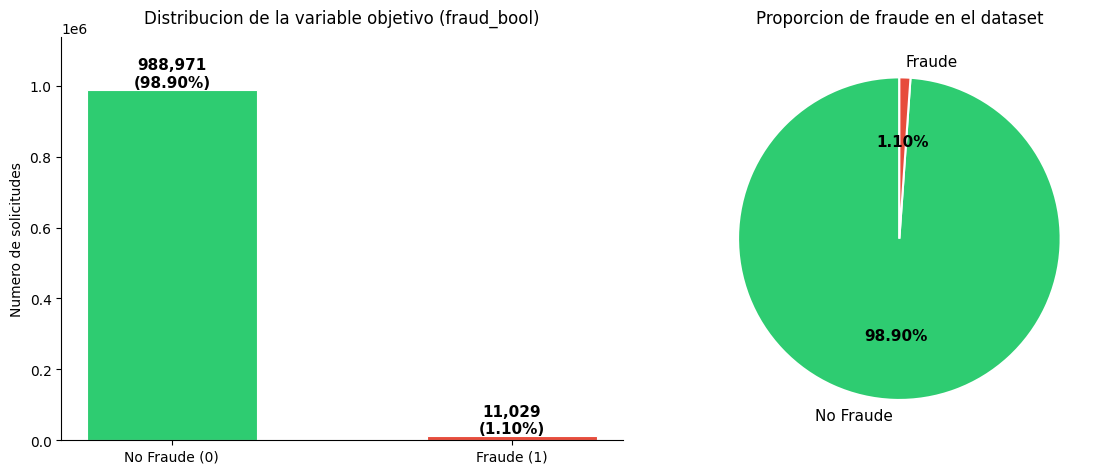

Total solicitudes:  1,000,000
No fraudulentas:    988,971 (98.90%)
Fraudulentas:       11,029 (1.10%)
Ratio de desbalanceo: 1:89


In [5]:
counts = df['fraud_bool'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
labels_target = ['No Fraude (0)', 'Fraude (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico de barras
bars = axes[0].bar(labels_target, counts.values, color=colors,
                   edgecolor='white', linewidth=0.8, width=0.5)
axes[0].set_title('Distribucion de la variable objetivo (fraud_bool)', fontsize=12, pad=10)
axes[0].set_ylabel('Numero de solicitudes')
axes[0].set_ylim(0, counts.max() * 1.15)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
                f'{val:,}\n({val/len(df)*100:.2f}%)',
                ha='center', fontsize=11, fontweight='bold')

# Grafico circular
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=['No Fraude', 'Fraude'],
    autopct='%1.2f%%', colors=colors, startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Proporcion de fraude en el dataset', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('../figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total solicitudes:  {len(df):,}')
print(f'No fraudulentas:    {counts[0]:,} ({counts[0]/len(df)*100:.2f}%)')
print(f'Fraudulentas:       {counts[1]:,} ({counts[1]/len(df)*100:.2f}%)')
print(f'Ratio de desbalanceo: 1:{counts[0]//counts[1]}')

## 5. Analisis de distribuciones

Se analiza la distribucion de cada tipo de variable para identificar asimetrias, valores especiales y patrones que condicionen el preprocesado posterior.

### 5.1. Variables continuas

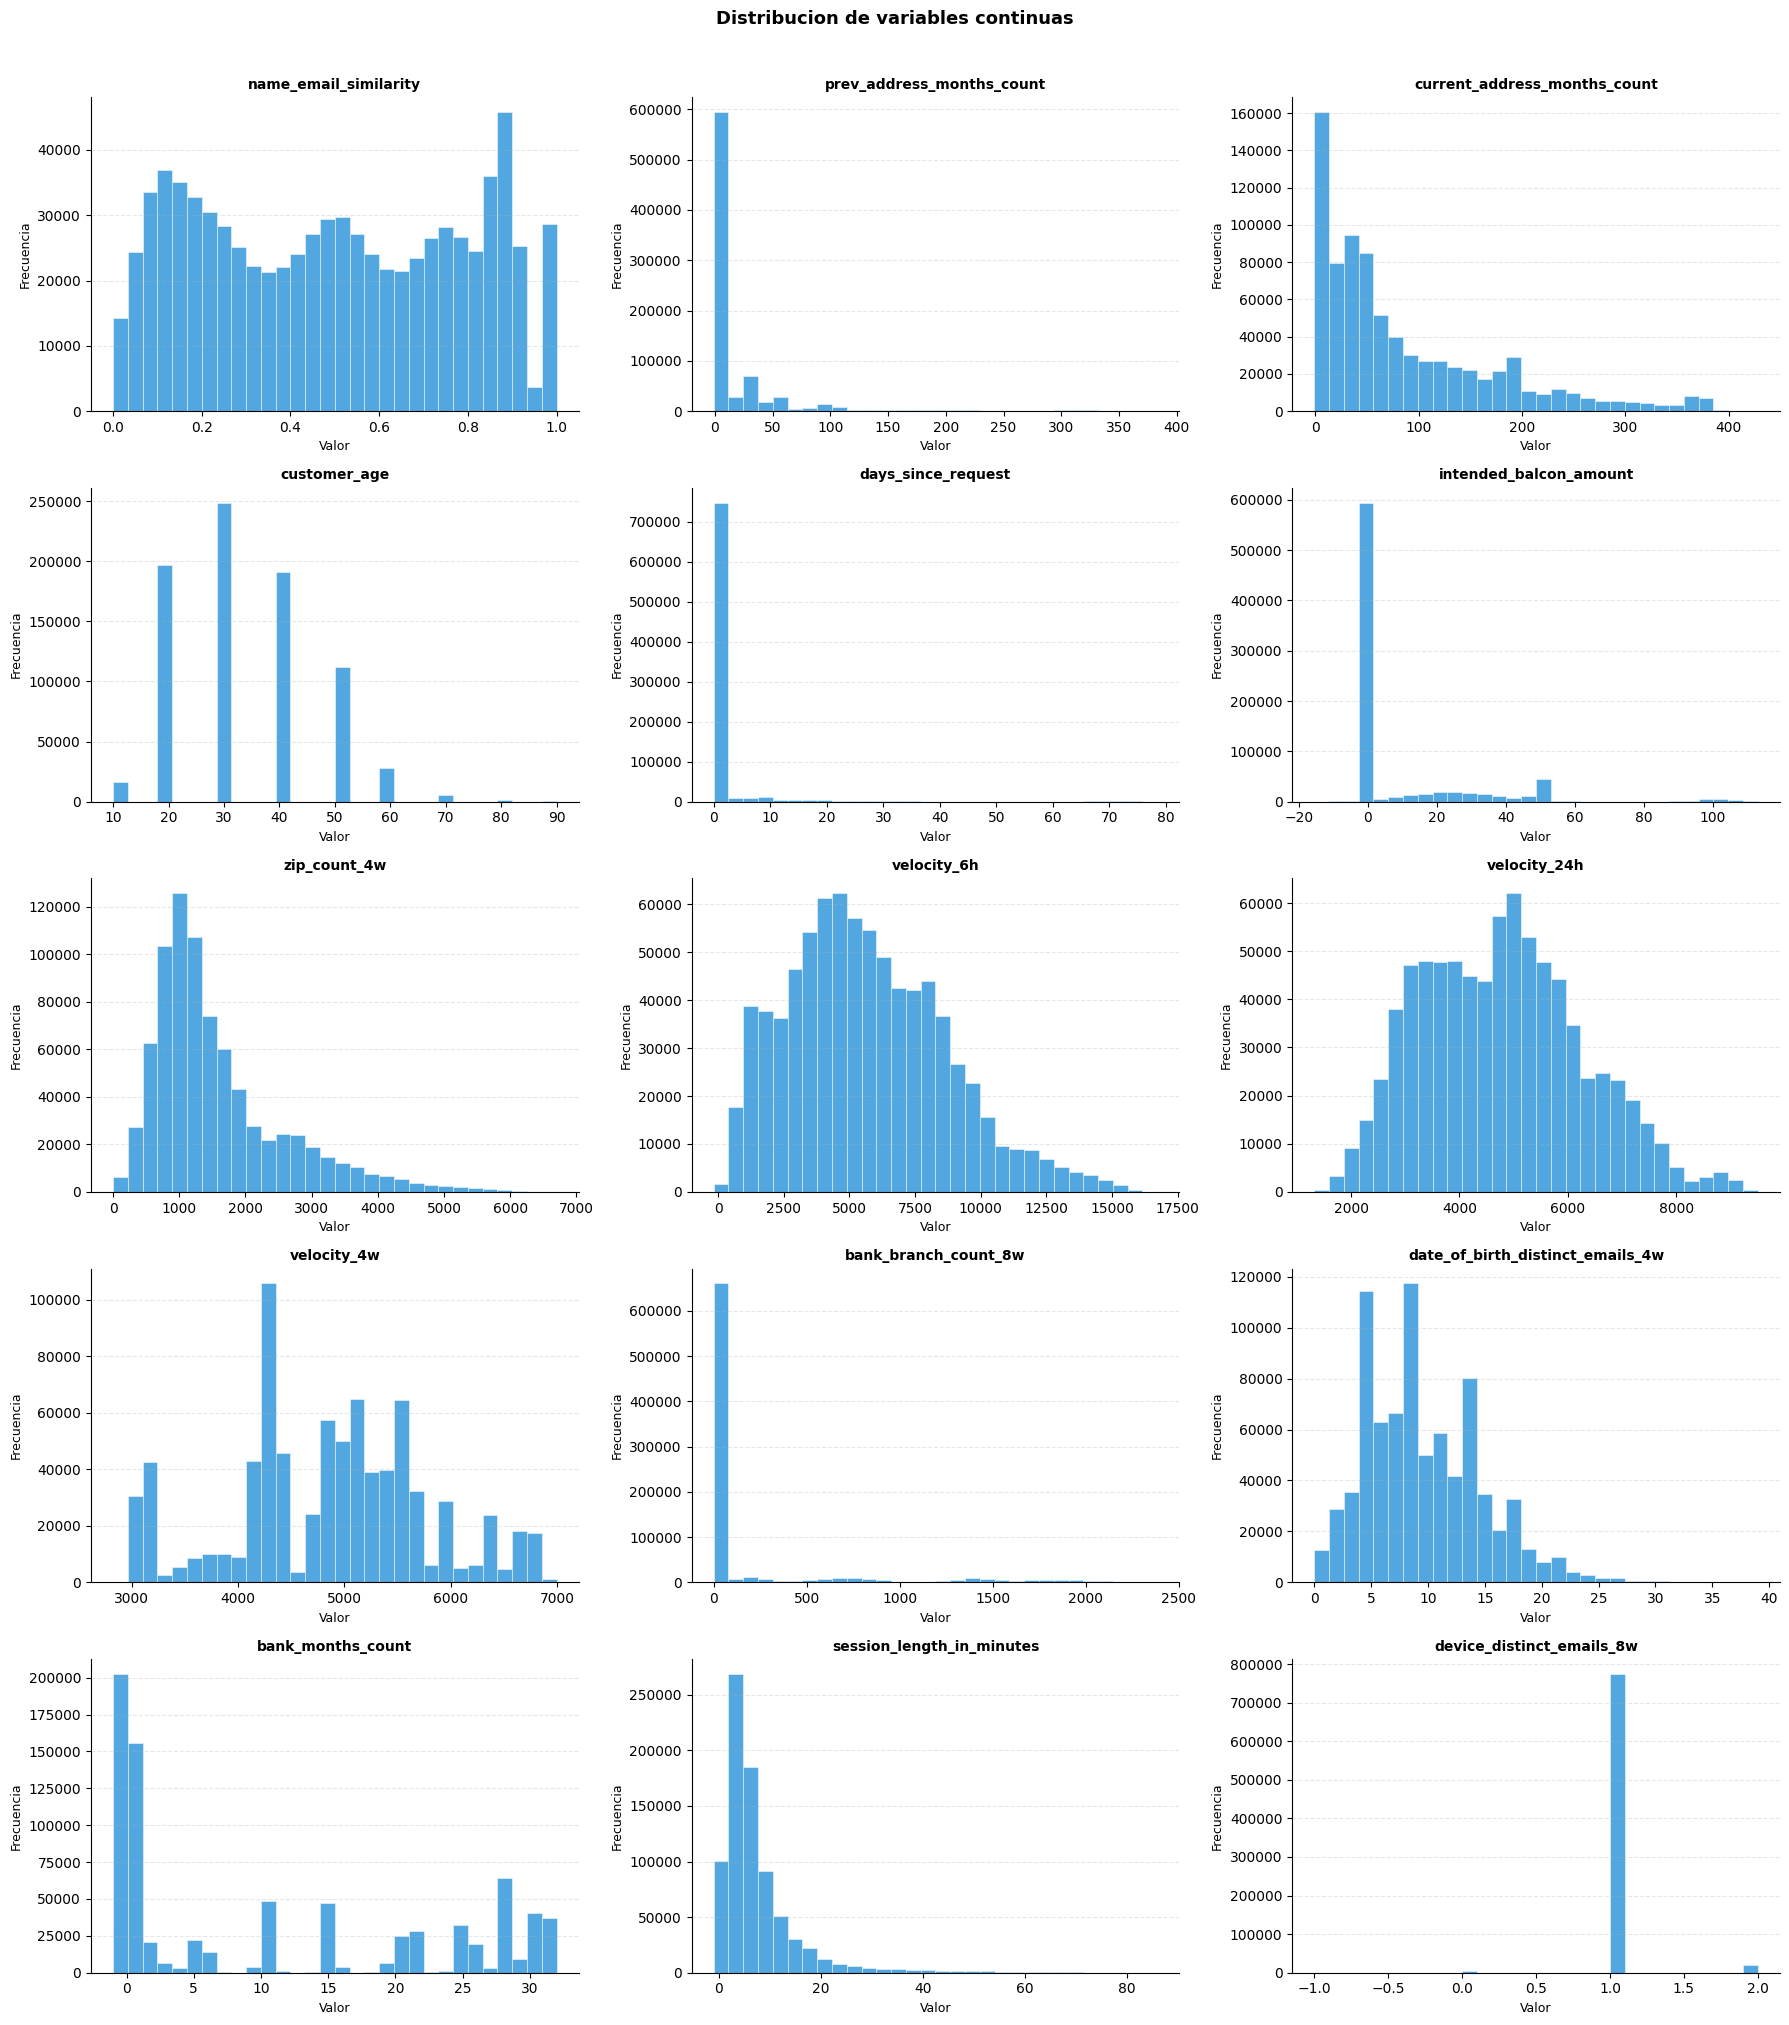

In [6]:
all_numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

truly_discrete_vars = [
    'phone_home_valid', 'phone_mobile_valid', 'foreign_request',
    'device_fraud_count', 'email_is_free', 'has_other_cards',
    'keep_alive_session', 'month', 'income', 'proposed_credit_limit'
]

continuous_vars = [col for col in all_numeric_cols if col not in truly_discrete_vars]

num_vars = len(continuous_vars)
n_cols = 3
n_rows = (num_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(continuous_vars):
    ax = axes[i]
    ax.hist(X_train[var], bins=30, color='#3498db',
            edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribucion de variables continuas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/continuous_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Hallazgos principales:**

1. **Sesgo positivo y colas largas** en variables como `zip_count_4w`, `bank_branch_count_8w` y `session_length_in_minutes`, con presencia de outliers extremos.
2. **Valores centinela (-1)** en varias variables que indican ausencia de informacion y deben tratarse explicitamente antes del entrenamiento.
3. **Patrones multimodales** en `name_email_similarity` y `velocity_4w`, lo que sugiere subgrupos de comportamiento diferenciado.

**Tratamiento recomendado:** transformaciones robustas (`log1p`, winsorizado) en variables muy sesgadas, y creacion de flags binarios para los valores centinela -1.

### 5.2. Variables discretas

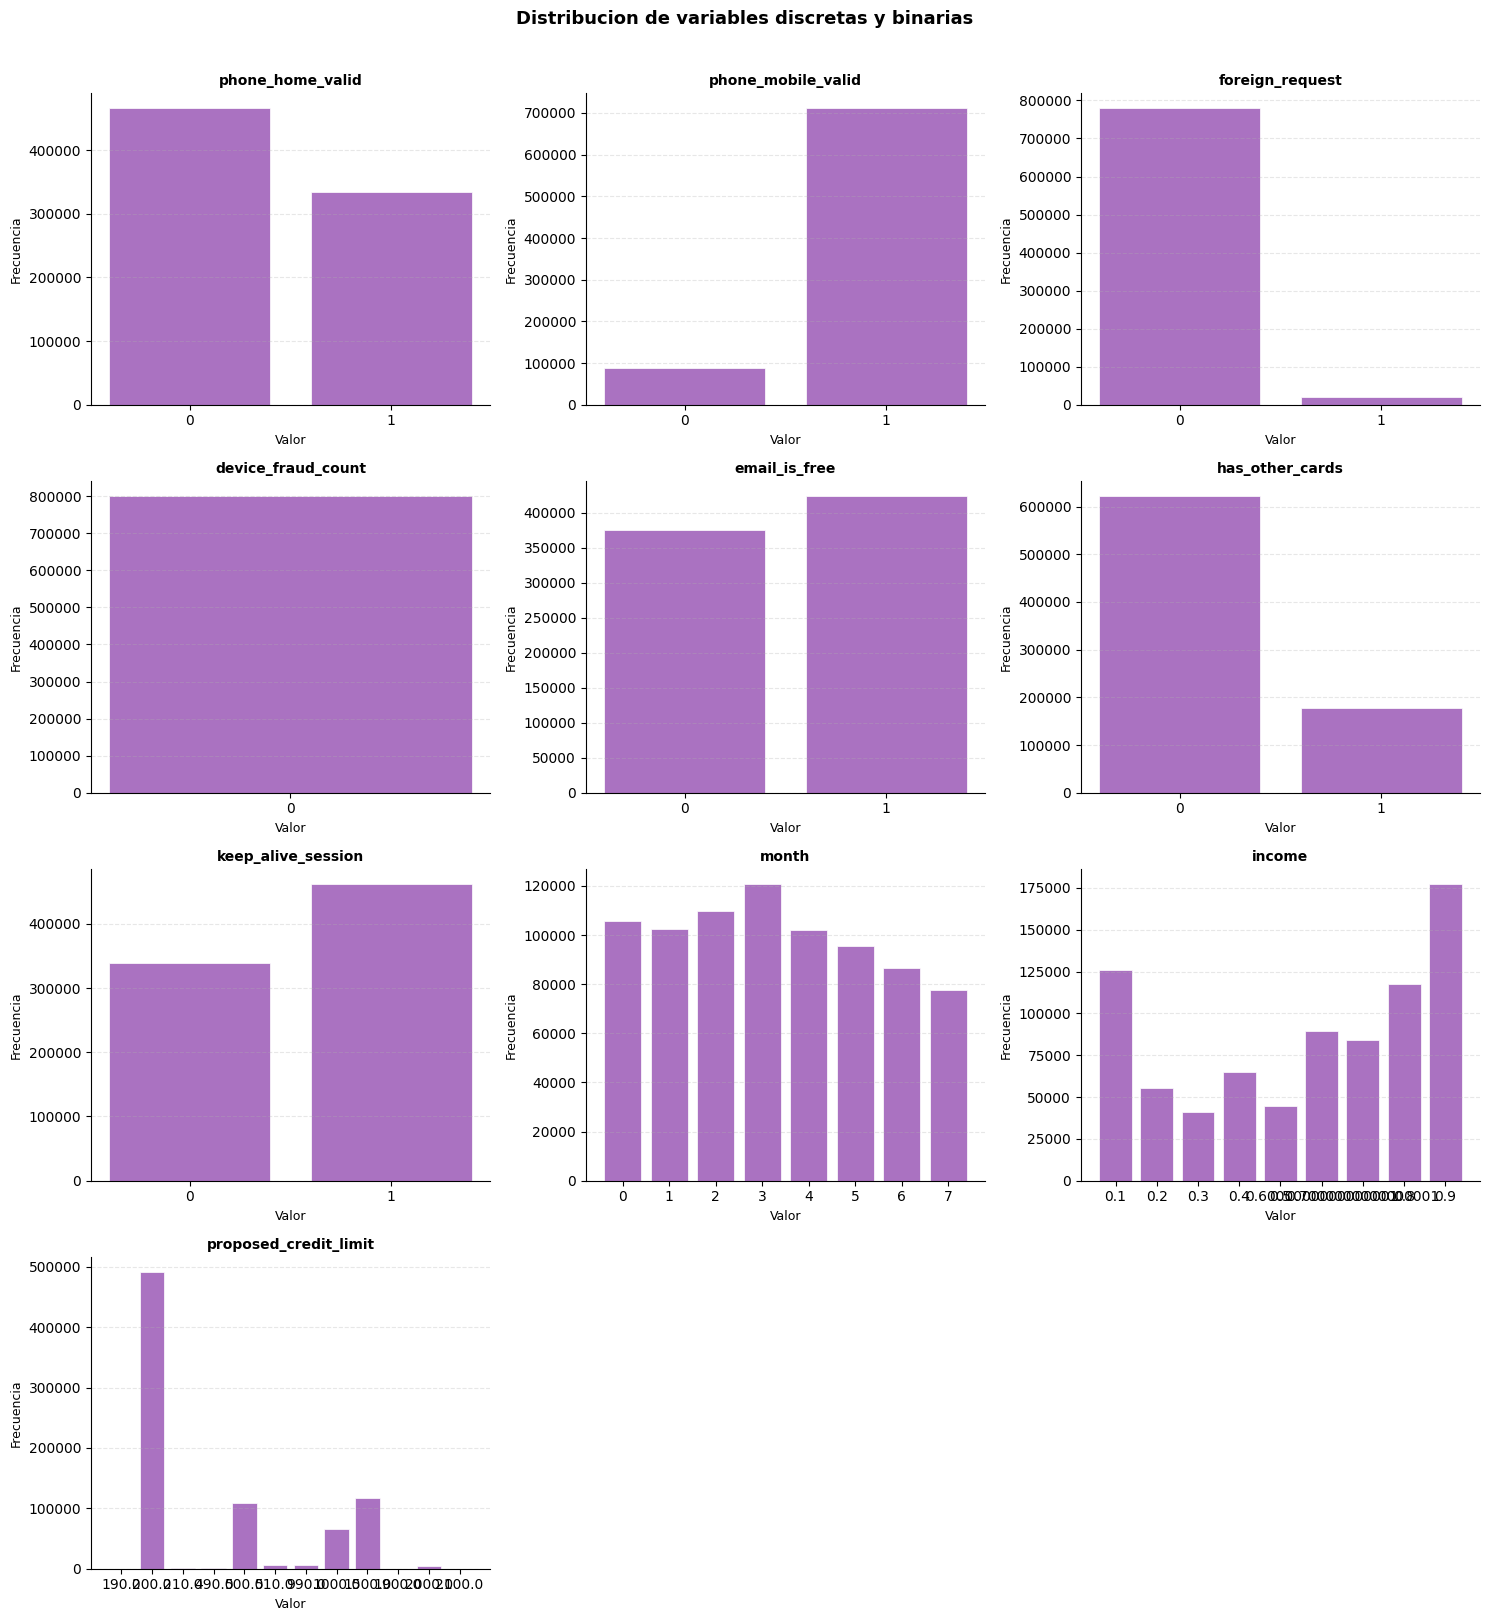

In [7]:
truly_discrete_vars = [v for v in truly_discrete_vars if v in X_train.columns]

num_vars = len(truly_discrete_vars)
n_cols = 3
n_rows = (num_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(truly_discrete_vars):
    ax = axes[i]
    freq = X_train[var].value_counts().sort_index()
    ax.bar(freq.index.astype(str), freq.values,
           color='#9b59b6', edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribucion de variables discretas y binarias', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/discrete_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Hallazgos principales:**

- **Desbalance en variables binarias**: `foreign_request`, `has_other_cards` y `phone_mobile_valid` presentan una clase claramente dominante.
- **Varianza nula en `device_fraud_count`**: practicamente todos los registros toman valor 0. Esta variable aporta informacion predictiva minima y debe considerarse su exclusion.
- **No uniformidad temporal en `month`**: hay estacionalidad que debe tenerse en cuenta en la validacion del modelo.
- **`income` y `proposed_credit_limit` discretizados por niveles**: aunque numericas, su comportamiento es ordinal.

### 5.3. Variables categoricas

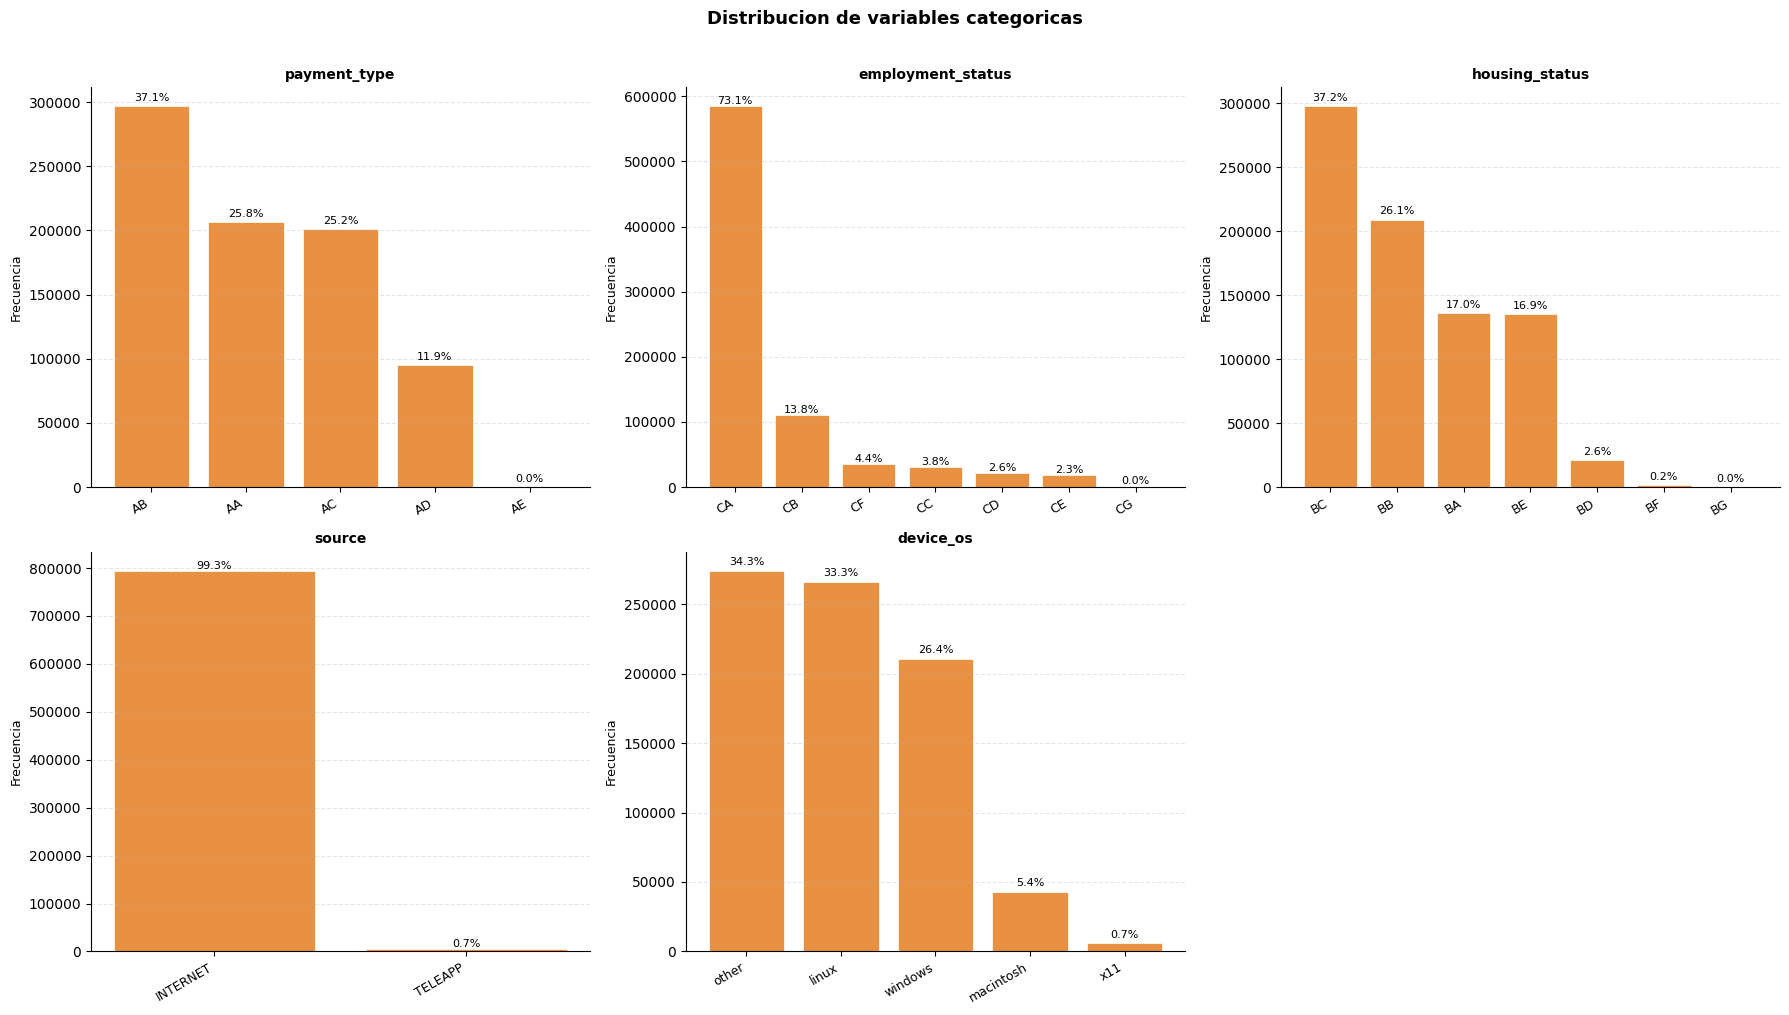

In [8]:
categorical_vars = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

num_vars = len(categorical_vars)
n_cols = 3
n_rows = (num_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    ax = axes[i]
    freq = X_train[var].value_counts()
    bars = ax.bar(range(len(freq)), freq.values,
                  color='#e67e22', edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.set_xticks(range(len(freq)))
    ax.set_xticklabels(freq.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    # Porcentaje sobre cada barra
    total = freq.sum()
    for bar, val in zip(bars, freq.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                f'{val/total*100:.1f}%', ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribucion de variables categoricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Hallazgos principales:**

- **Desbalance severo en `source`**: mas del 95% de las solicitudes proceden de INTERNET.
- **Categoria dominante en `employment_status`**: la categoria CA concentra la mayoria de registros.
- **Categorias raras** (`AE`, `CG`, `BG`, `BF`, `X11`): muy pocas muestras, con riesgo de inestabilidad en la estimacion y sobreajuste.

**Tratamiento recomendado:** agrupacion de categorias raras bajo un valor `OTHER` segun umbral de frecuencia minima, codificacion one-hot con regularizacion.

## 6. Analisis de correlaciones

Se calculan las correlaciones de Pearson entre variables numericas para identificar relaciones lineales, redundancias potenciales y la señal individual de cada variable respecto a la variable objetivo.

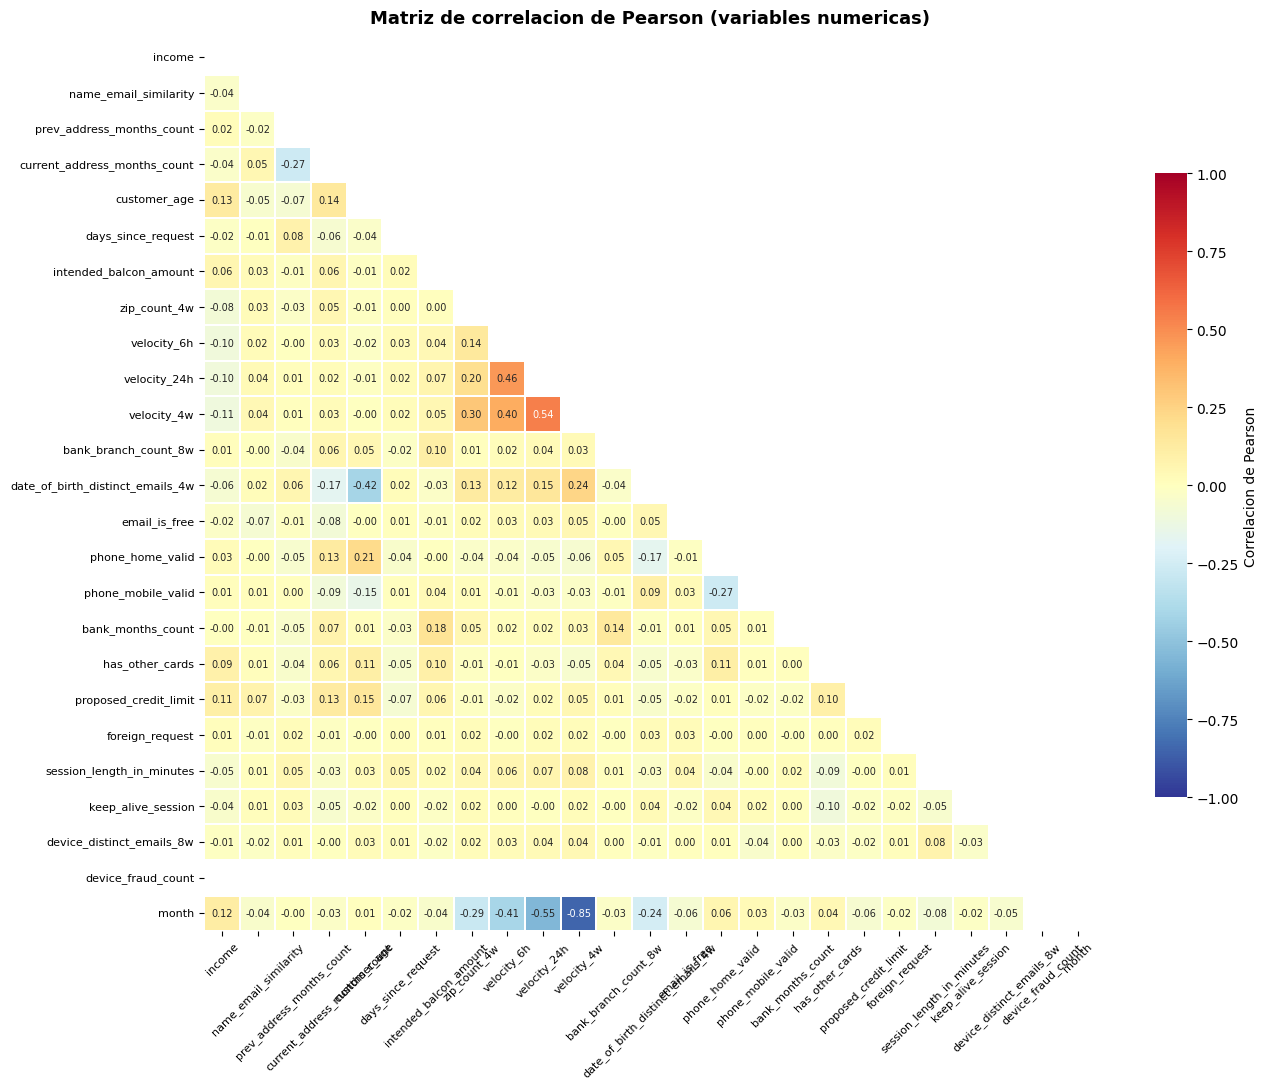

Top 10 correlaciones por valor absoluto:


,Variable 1,Variable 2,Correlacion
274,velocity_4w,month,-0.847853
249,velocity_24h,month,-0.550243
235,velocity_24h,velocity_4w,0.539310
209,velocity_6h,velocity_24h,0.464362
112,customer_age,date_of_birth_distinct_emails_4w,-0.421290
224,velocity_6h,month,-0.409136
210,velocity_6h,velocity_4w,0.400211
185,zip_count_4w,velocity_4w,0.302746
199,zip_count_4w,month,-0.286883
53,prev_address_months_count,current_address_months_count,-0.272392


In [9]:
numeric_df = X_train.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Heatmap con mascara triangular superior para evitar duplicados
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'Correlacion de Pearson'}
)
ax.set_title('Matriz de correlacion de Pearson (variables numericas)',
             fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlaciones (excluyendo diagonal y duplicados)
corr_long = corr_matrix.unstack().reset_index()
corr_long.columns = ['Variable 1', 'Variable 2', 'Correlacion']
corr_long = corr_long[corr_long['Variable 1'] != corr_long['Variable 2']]
corr_long['ParOrdenado'] = corr_long.apply(
    lambda r: tuple(sorted([r['Variable 1'], r['Variable 2']])), axis=1
)
corr_long = corr_long.drop_duplicates(subset='ParOrdenado').drop(columns='ParOrdenado')
corr_long['AbsCorr'] = corr_long['Correlacion'].abs()
top_corr = corr_long.sort_values('AbsCorr', ascending=False).head(10)

print('Top 10 correlaciones por valor absoluto:')
display(top_corr[['Variable 1', 'Variable 2', 'Correlacion']])

Las correlaciones mas destacables entre variables numericas son:

- `velocity_4w` / `month` (-0.589): a menor mes, mayor velocidad de solicitudes, coherente con picos de actividad fuera del periodo festivo.
- `customer_age` / `date_of_birth_distinct_emails_4w` (-0.448): logico dado que la piramide poblacional decrece con la edad.
- `velocity_6h` / `velocity_24h` (+0.333): esperado, ya que ambas miden actividad en ventanas temporales solapadas.
- `phone_home_valid` / `phone_mobile_valid` (-0.300): refleja la sustitucion progresiva del telefono fijo por el movil.

Ninguna variable individual presenta una correlacion fuerte con `fraud_bool` (maximo |r| ~ 0.10-0.15), lo que confirma que la deteccion de fraude es un problema intrinsecamente multivariante.

## 7. Analisis por variable categorica

### 7.1. Relacion con variables numericas

Se analiza la media de las variables numericas agrupada por cada variable categorica para identificar perfiles de comportamiento diferenciados entre sus categorias.

In [10]:
var_groups = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

for var in var_groups:
    print(f'\n--- Medias por {var} ---')
    display(X_train.groupby(var).mean(numeric_only=True).round(3))


--- Medias por payment_type ---


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
payment_type,,,,,,,,,,,,,,,,,,,,,,,,,
AA,0.582,0.506,15.990,95.699,33.152,1.426,33.462,1600.071,6030.351,4980.908,4956.501,290.993,9.344,0.515,0.426,0.919,15.811,0.316,508.333,0.026,8.010,0.561,1.012,0.0,3.084
AB,0.555,0.480,14.137,86.347,34.806,0.361,0.067,1549.566,5452.473,4638.890,4770.171,223.974,9.290,0.536,0.458,0.881,13.949,0.211,537.241,0.025,7.083,0.586,1.020,0.0,3.487
AC,0.543,0.498,21.249,79.125,33.399,1.850,-0.704,1527.440,5520.360,4670.353,4783.205,11.107,9.385,0.521,0.361,0.872,-0.017,0.184,485.321,0.021,7.700,0.565,1.020,0.0,3.427
AD,0.587,0.501,16.585,83.525,32.081,0.470,1.381,1681.915,5830.575,4932.336,5059.161,195.318,10.773,0.563,0.389,0.889,13.394,0.136,532.024,0.035,7.682,0.610,1.026,0.0,2.821
AE,0.544,0.473,28.952,96.009,33.290,1.748,14.707,1517.177,6062.701,5197.041,4968.798,175.645,9.749,0.511,0.364,0.810,13.299,0.229,566.710,0.039,8.506,0.485,1.035,0.0,2.870



--- Medias por employment_status ---


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
employment_status,,,,,,,,,,,,,,,,,,,,,,,,,
CA,0.569,0.503,17.705,83.074,32.588,1.037,8.877,1547.965,5552.320,4705.720,4812.347,177.069,9.710,0.528,0.387,0.903,10.730,0.222,539.274,0.025,7.449,0.580,1.017,0.0,3.399
CB,0.617,0.462,12.566,98.145,35.045,0.957,9.819,1696.628,6079.632,5037.250,5055.944,206.350,9.964,0.535,0.462,0.894,11.706,0.223,503.173,0.032,7.291,0.602,1.013,0.0,2.788
CC,0.526,0.447,13.988,129.673,51.641,0.697,5.704,1544.579,5838.638,4898.367,4915.921,223.264,4.032,0.522,0.714,0.681,11.437,0.267,507.622,0.021,9.578,0.445,1.057,0.0,3.169
CD,0.435,0.477,17.013,75.539,34.602,1.645,4.928,1609.790,5967.515,4922.806,4930.440,171.207,9.340,0.540,0.404,0.847,9.171,0.188,334.270,0.021,8.485,0.520,1.026,0.0,3.066
CE,0.420,0.553,13.468,100.390,27.040,1.092,12.632,1573.494,5884.070,4863.213,4831.486,224.445,9.253,0.509,0.390,0.920,12.564,0.135,362.287,0.018,7.863,0.550,1.015,0.0,3.312
CF,0.475,0.467,16.748,71.754,35.378,0.883,4.246,1598.661,5767.554,4753.338,4870.655,188.658,9.583,0.560,0.538,0.831,9.749,0.262,366.827,0.020,7.563,0.617,1.021,0.0,3.253
CG,0.575,0.461,21.159,90.922,35.914,1.341,11.689,1485.051,5848.973,4862.912,4813.588,216.626,8.831,0.492,0.457,0.876,11.685,0.304,569.167,0.054,8.357,0.465,0.997,0.0,3.360



--- Medias por housing_status ---


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
housing_status,,,,,,,,,,,,,,,,,,,,,,,,,
BA,0.659,0.489,10.364,132.960,39.679,0.604,8.482,1537.204,5187.089,4581.855,4772.103,185.547,7.826,0.461,0.453,0.842,10.901,0.259,824.817,0.029,6.881,0.506,1.018,0.0,3.510
BB,0.530,0.486,15.306,84.759,36.280,0.886,4.334,1560.454,5631.143,4701.571,4819.397,184.199,8.972,0.536,0.483,0.871,10.045,0.239,445.546,0.019,7.722,0.597,1.025,0.0,3.398
BC,0.583,0.482,23.392,46.738,32.943,1.315,10.122,1555.243,5732.183,4851.128,4887.112,176.928,10.139,0.574,0.376,0.908,10.418,0.227,464.344,0.029,7.964,0.588,1.016,0.0,3.180
BD,0.587,0.468,22.373,76.230,34.395,1.285,9.255,1457.792,5342.767,4508.527,4661.690,190.396,9.010,0.585,0.445,0.897,10.844,0.218,536.854,0.029,7.824,0.616,1.018,0.0,3.753
BE,0.469,0.542,9.577,132.131,25.254,0.971,12.193,1683.763,6090.639,4925.552,4956.949,197.843,10.696,0.484,0.365,0.924,12.969,0.152,426.285,0.022,7.001,0.588,1.013,0.0,3.067
BF,0.559,0.463,21.694,94.616,34.493,1.757,12.453,1548.381,5949.730,4977.181,4947.248,235.604,9.195,0.529,0.478,0.854,12.602,0.264,448.111,0.026,7.548,0.525,1.007,0.0,2.994
BG,0.552,0.546,18.939,105.571,34.343,1.467,21.560,1790.035,5747.343,5097.461,5270.670,268.384,10.167,0.414,0.475,0.879,12.500,0.313,541.970,0.025,8.308,0.540,1.035,0.0,2.429



--- Medias por source ---


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
source,,,,,,,,,,,,,,,,,,,,,,,,,
INTERNET,0.563,0.494,16.733,86.547,33.675,1.016,8.687,1572.998,5664.990,4769.281,4855.938,184.767,9.514,0.530,0.417,0.890,10.877,0.222,516.456,0.025,7.577,0.581,1.021,0.0,3.289
TELEAPP,0.534,0.466,12.150,96.062,37.228,2.157,5.532,1540.194,5527.673,4904.279,4865.165,118.876,8.112,0.529,0.492,0.805,6.924,0.319,464.745,0.010,3.770,0.083,0.604,0.0,3.248



--- Medias por device_os ---


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
device_os,,,,,,,,,,,,,,,,,,,,,,,,,
linux,0.536,0.474,19.064,78.040,34.311,1.112,7.528,1620.953,5769.057,4800.497,4896.496,177.737,9.512,0.626,0.432,0.901,10.352,0.231,472.259,0.034,8.036,0.594,1.023,0.0,3.167
macintosh,0.598,0.503,19.047,84.341,31.339,1.069,11.060,1538.966,5614.699,4773.994,4774.684,185.634,9.415,0.526,0.334,0.908,11.249,0.202,539.768,0.030,7.624,0.472,1.018,0.0,3.501
other,0.573,0.499,15.162,89.588,31.874,1.038,10.437,1542.561,5648.070,4762.233,4830.137,187.498,9.881,0.440,0.392,0.907,10.660,0.238,492.066,0.013,6.853,0.599,1.007,0.0,3.384
windows,0.576,0.510,15.118,94.045,35.721,0.868,7.151,1557.103,5556.503,4739.021,4853.935,186.628,9.047,0.525,0.449,0.848,11.604,0.198,597.356,0.028,7.791,0.550,1.028,0.0,3.274
x11,0.594,0.497,21.113,86.276,35.997,1.651,14.404,1608.855,5872.244,4866.402,4898.806,240.063,8.629,0.589,0.434,0.866,12.200,0.189,532.540,0.033,8.849,0.543,1.025,0.0,3.277


Las variables categoricas con mayor desbalance (`source`, `employment_status`) tienden a mostrar perfiles numericos menos diferenciados, ya que la categoria dominante condiciona la media global. Variables con distribucion mas equilibrada como `device_os`, `housing_status` y `payment_type` revelan diferencias mas informativas entre categorias en variables como `intended_balcon_amount` o las velocidades de solicitud.

La utilidad predictiva real de estas variables reside principalmente en su interaccion con otras caracteristicas dentro de modelos no lineales.

### 7.2. Relaciones entre variables categoricas

Se cuantifica la asociacion entre las propias variables categoricas mediante el coeficiente **V de Cramer**, que mide la fuerza de asociacion entre variables nominales (rango [0, 1], donde 0 indica independencia y 1 asociacion perfecta).

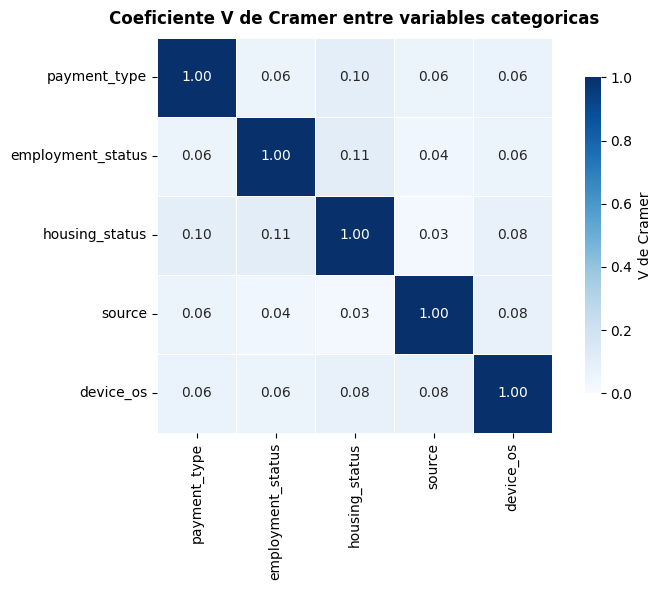

In [11]:
categorical_vars = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    k = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * k))

matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars, dtype=float)
for col1, col2 in itertools.product(categorical_vars, repeat=2):
    matrix.loc[col1, col2] = cramers_v(X_train[col1], X_train[col2])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues',
            square=True, linewidths=0.5, linecolor='white',
            vmin=0, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': "V de Cramer"})
ax.set_title("Coeficiente V de Cramer entre variables categoricas",
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../figures/cramers_v_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Los valores de V de Cramer son consistentemente bajos (mayoria entre 0.02 y 0.11), lo que indica que las variables categoricas son practicamente independientes entre si. Esto implica que cada variable aporta informacion mayormente no redundante, y que su valor predictivo debe buscarse en combinacion con variables numericas o con la variable objetivo, no en sus interacciones mutuas.

## 8. Analisis comparativo: Fraude vs. No Fraude

Para evaluar la capacidad discriminativa de las variables, se analizan las 10 variables numericas mas correlacionadas con `fraud_bool` mediante histogramas de densidad y boxplots separados por clase. La normalizacion por densidad permite comparar las distribuciones compensando el desbalanceo extremo.

Top 10 variables mas correlacionadas con fraud_bool (valor absoluto):
  proposed_credit_limit                     r = +0.0689
  customer_age                              r = +0.0630
  keep_alive_session                        r = -0.0503
  income                                    r = +0.0451
  date_of_birth_distinct_emails_4w          r = -0.0432
  name_email_similarity                     r = -0.0367
  device_distinct_emails_8w                 r = +0.0357
  has_other_cards                           r = -0.0352
  phone_home_valid                          r = -0.0351
  current_address_months_count              r = +0.0337


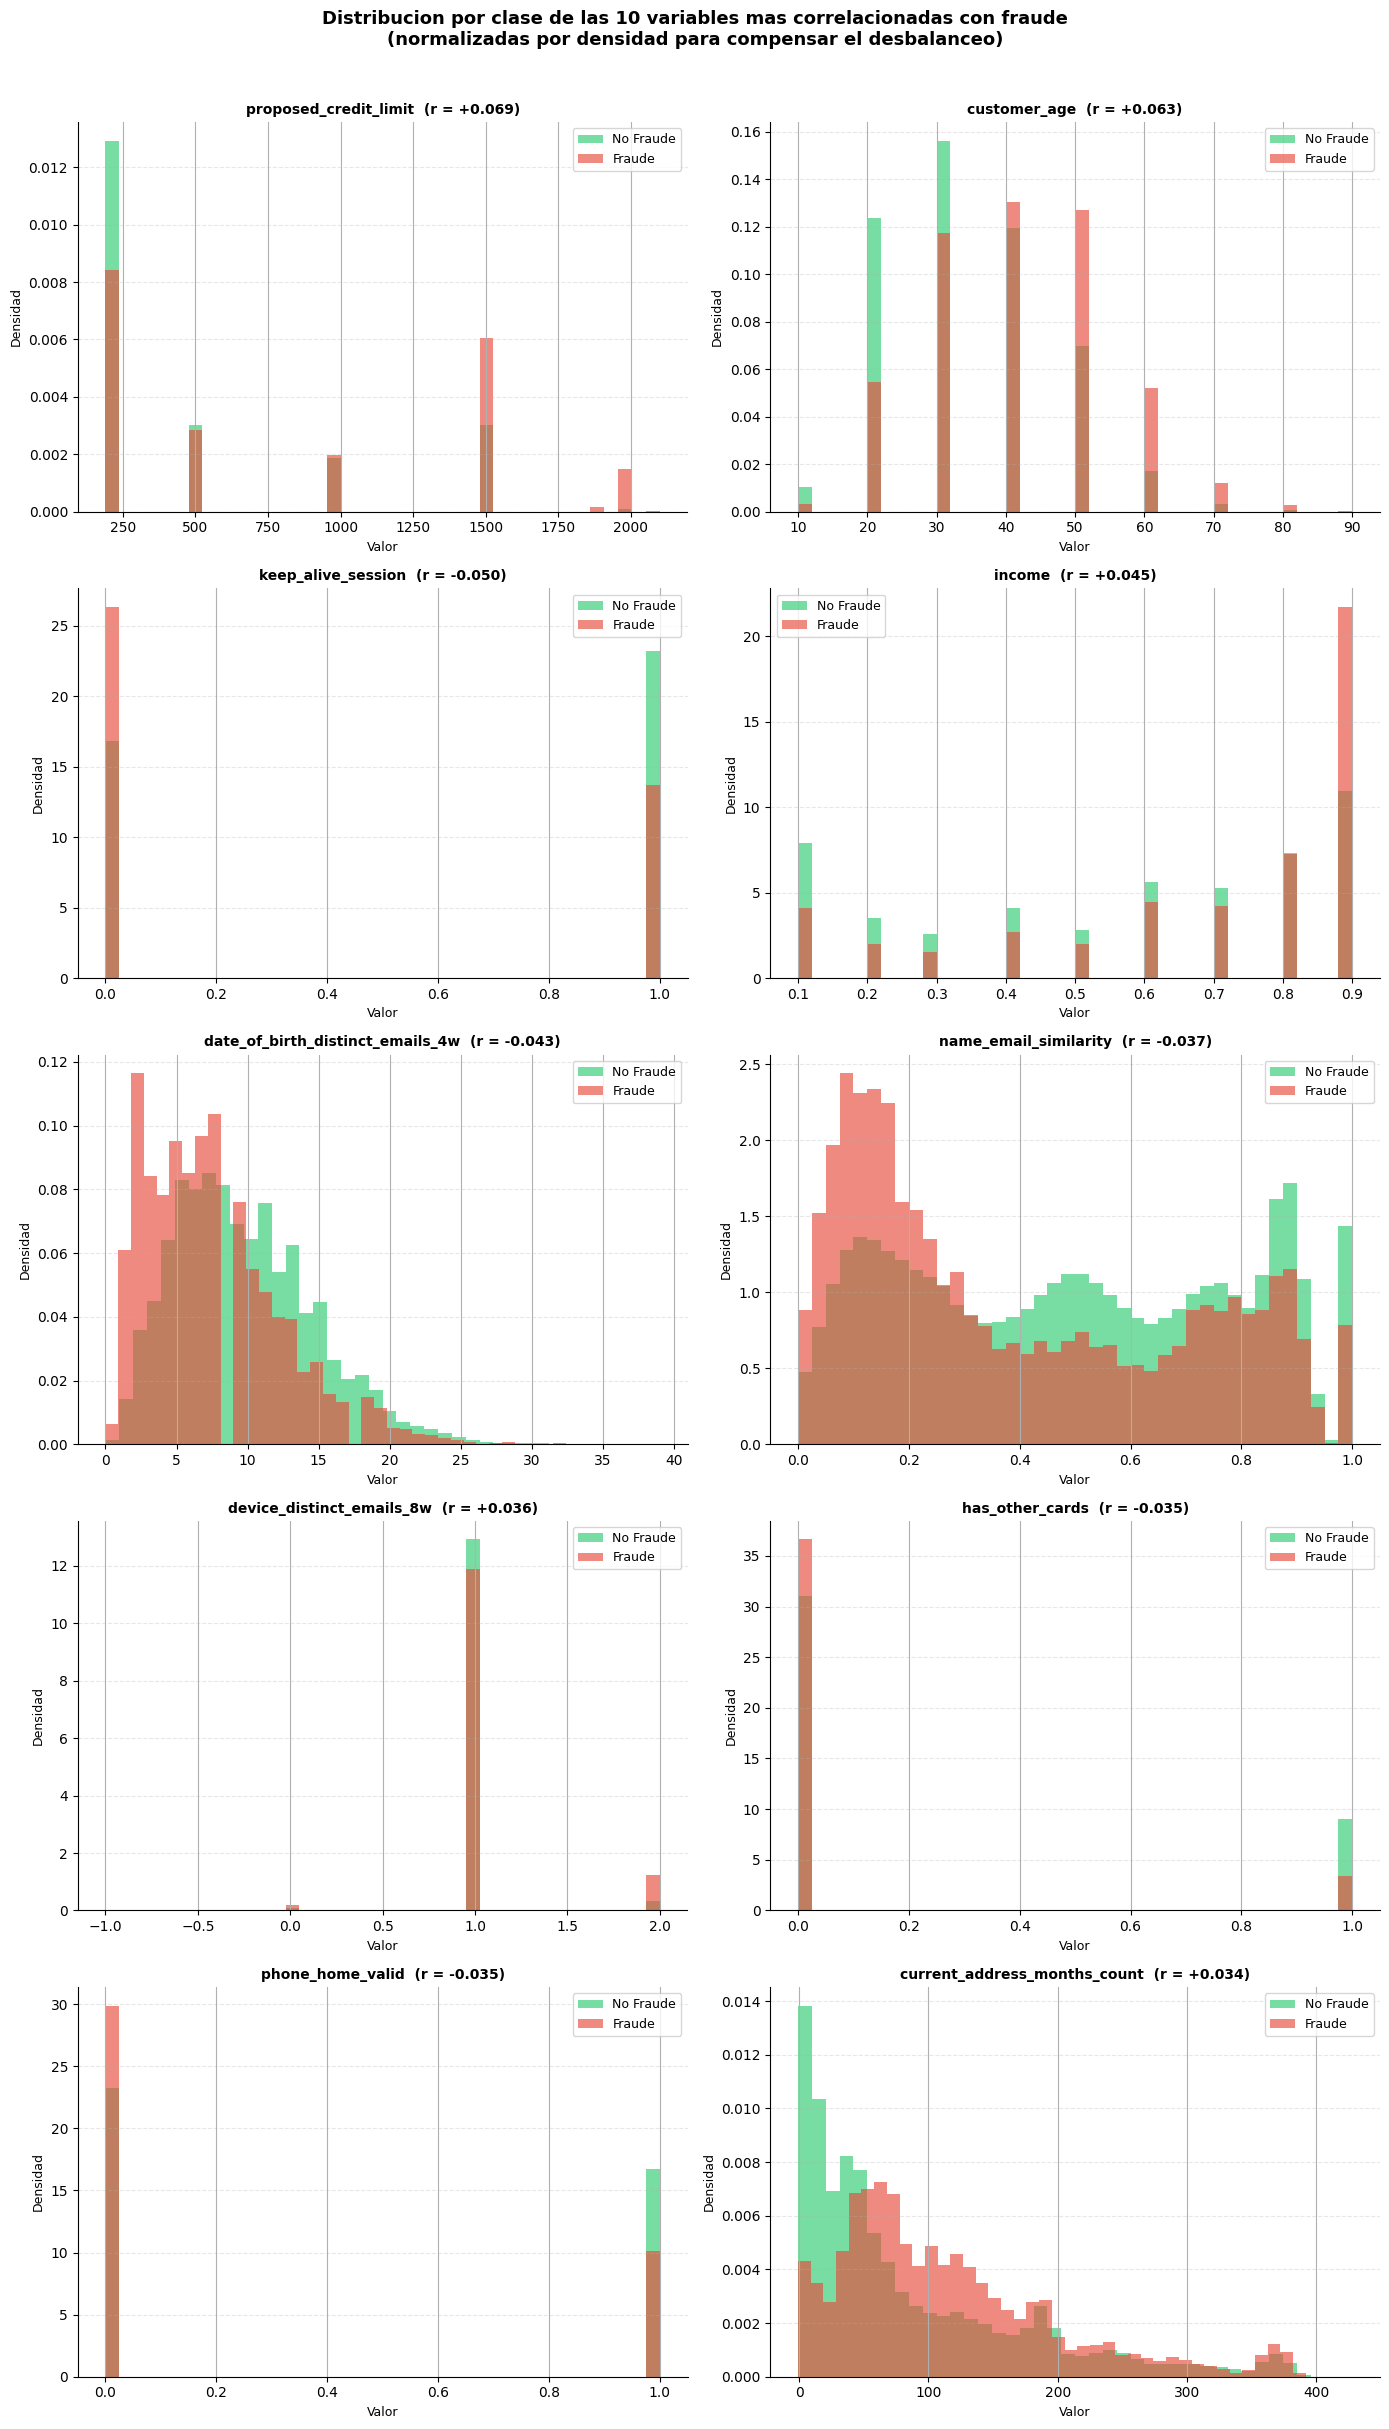

C:\Users\al3xc\AppData\Local\Temp\ipykernel_13904\3755108918.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=['No Fraude', 'Fraude'],
C:\Users\al3xc\AppData\Local\Temp\ipykernel_13904\3755108918.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=['No Fraude', 'Fraude'],
C:\Users\al3xc\AppData\Local\Temp\ipykernel_13904\3755108918.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=['No Fraude', 'Fraude'],
C:\Users\al3xc\AppData\Local\Temp\ipykernel_13904\3755108918.py:41: MatplotlibDeprecationWarning: The 'labels' p

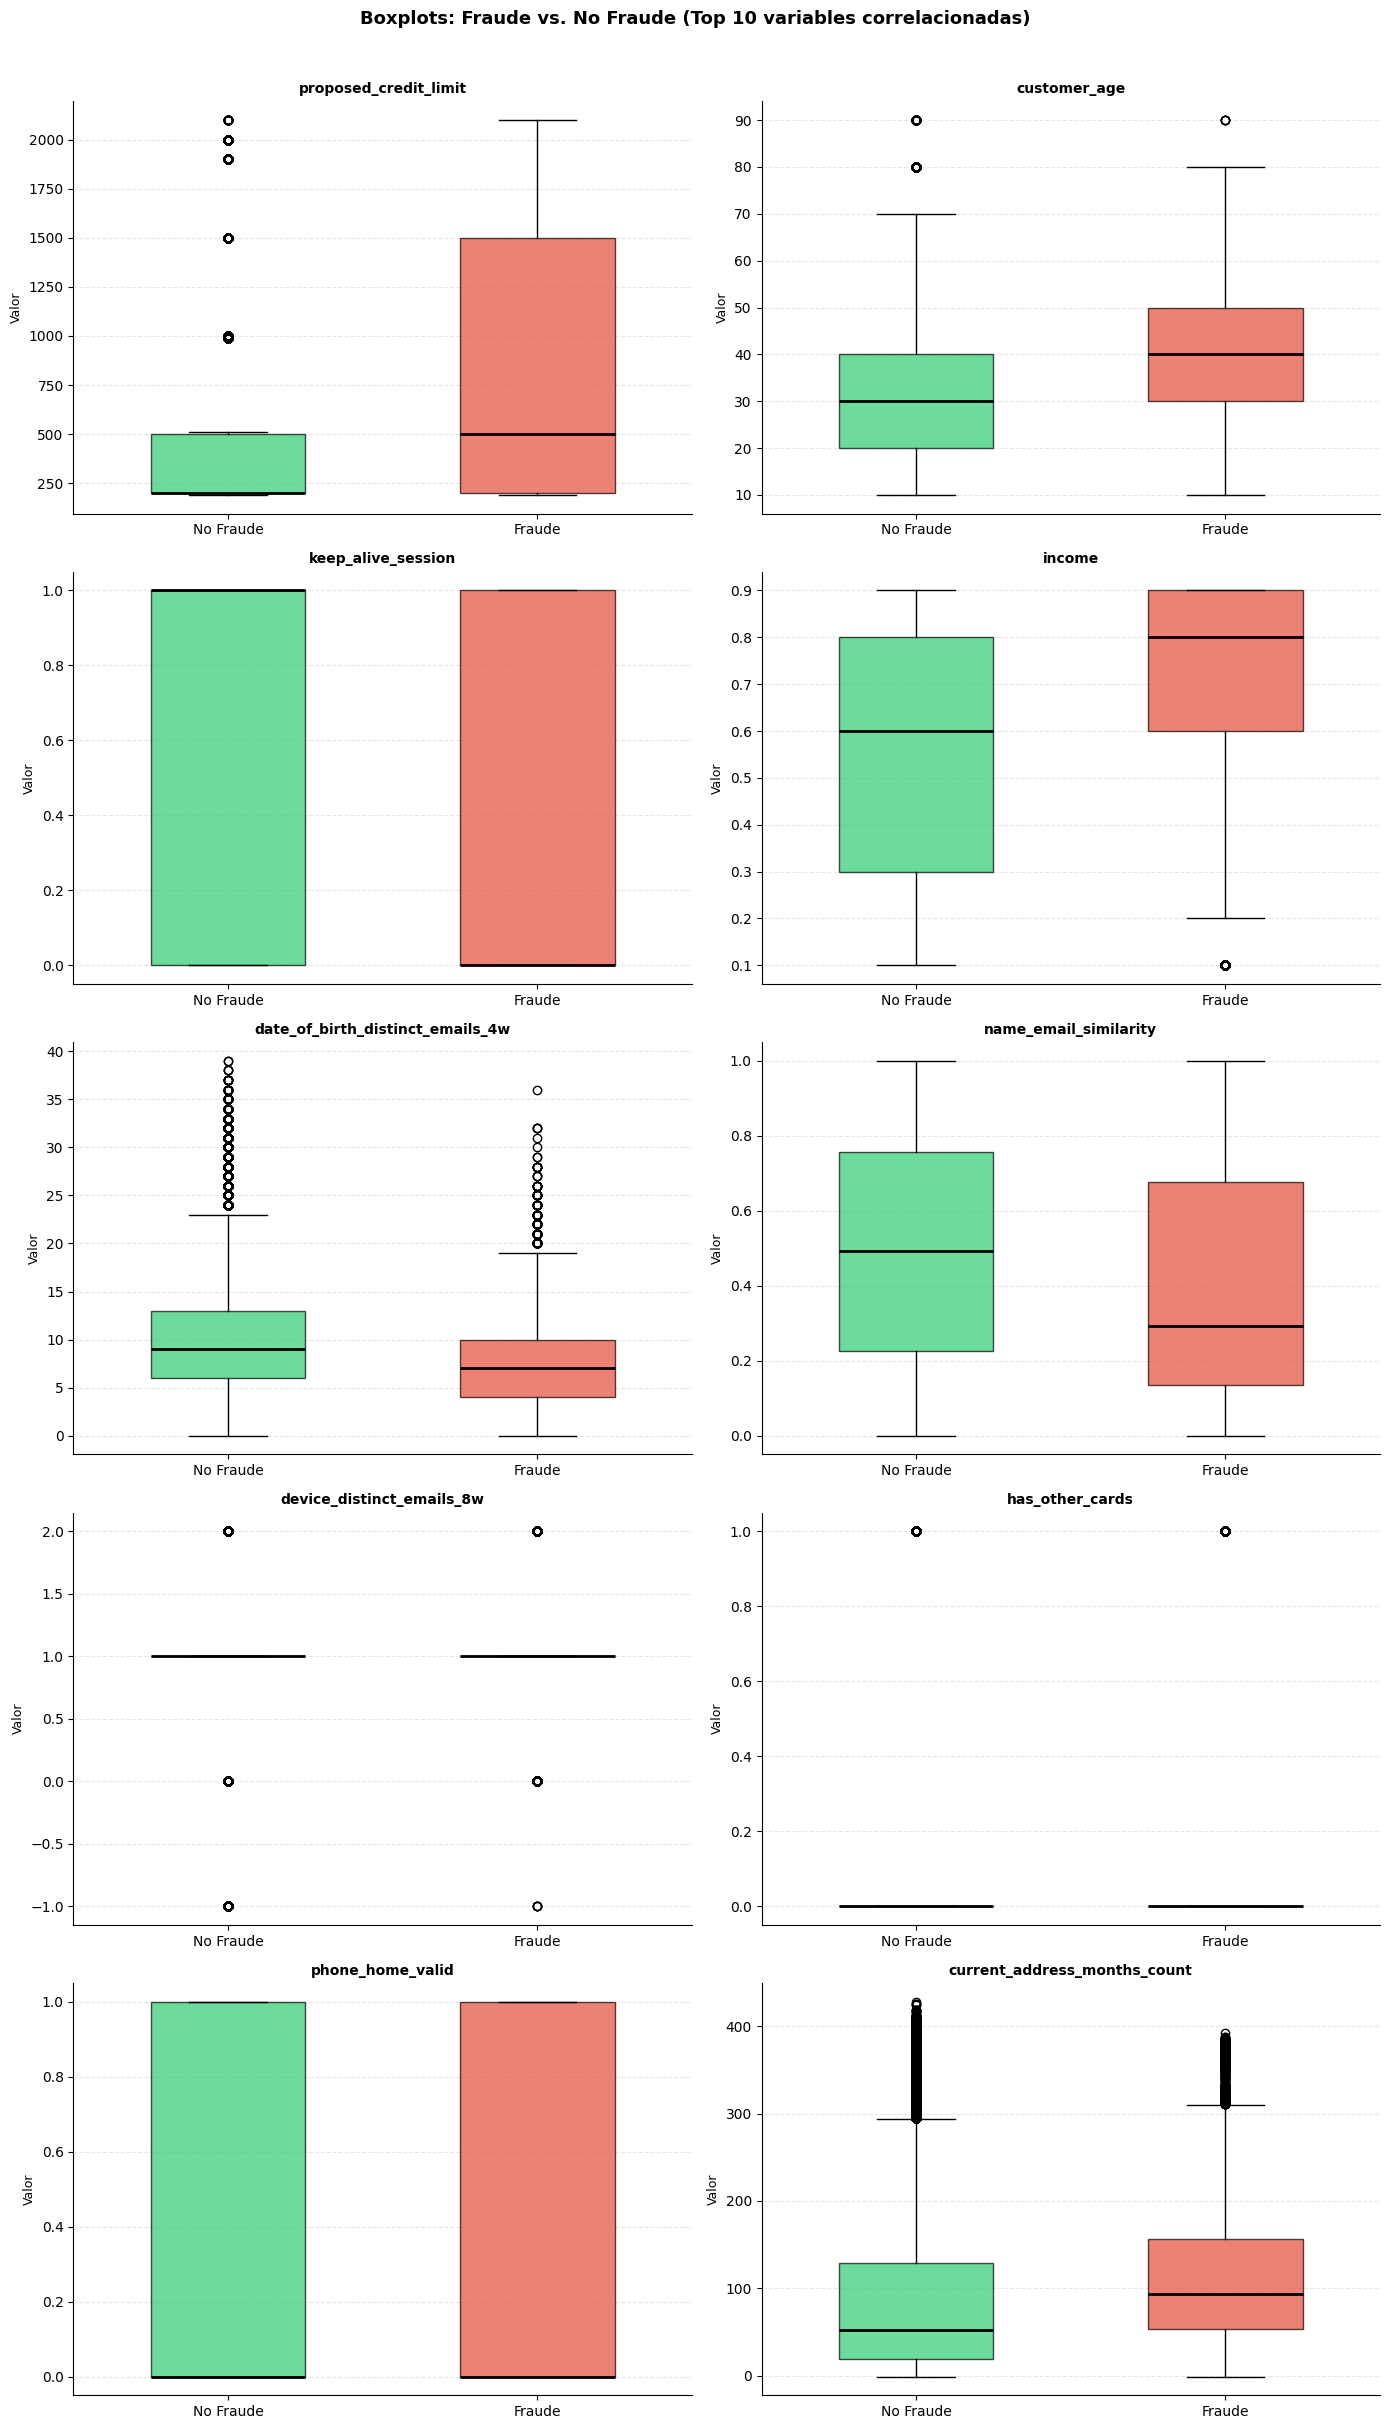

In [12]:
fraud_corr = df.select_dtypes(include='number').corr()['fraud_bool'].drop('fraud_bool')
fraud_corr_abs = fraud_corr.abs().sort_values(ascending=False)
top_vars = fraud_corr_abs.head(10).index.tolist()

print('Top 10 variables mas correlacionadas con fraud_bool (valor absoluto):')
print('=' * 60)
for var in top_vars:
    print(f'  {var:40s}  r = {fraud_corr[var]:+.4f}')

# Histogramas por clase
fig, axes = plt.subplots(5, 2, figsize=(14, 24))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    ax = axes[i]
    df[df['fraud_bool'] == 0][var].hist(bins=40, alpha=0.65, label='No Fraude',
                                         color='#2ecc71', ax=ax, density=True)
    df[df['fraud_bool'] == 1][var].hist(bins=40, alpha=0.65, label='Fraude',
                                         color='#e74c3c', ax=ax, density=True)
    ax.set_title(f'{var}  (r = {fraud_corr[var]:+.3f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Distribucion por clase de las 10 variables mas correlacionadas con fraude\n'
             '(normalizadas por densidad para compensar el desbalanceo)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/histograms_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplots por clase
fig, axes = plt.subplots(5, 2, figsize=(14, 24))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    ax = axes[i]
    data_bp = [df[df['fraud_bool'] == 0][var].dropna(),
               df[df['fraud_bool'] == 1][var].dropna()]
    bp = ax.boxplot(data_bp, labels=['No Fraude', 'Fraude'],
                    patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Valor', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Boxplots: Fraude vs. No Fraude (Top 10 variables correlacionadas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Deteccion de valores atipicos

Se aplica el metodo del **rango intercuartilico (IQR)** para cuantificar la presencia de outliers en cada variable numerica. En el contexto de deteccion de fraude, los valores atipicos no son necesariamente errores: los comportamientos anomalos (velocidades inusuales, multiples emails desde un mismo dispositivo, sesiones extremas) son precisamente las señales que el modelo debe aprender a identificar.

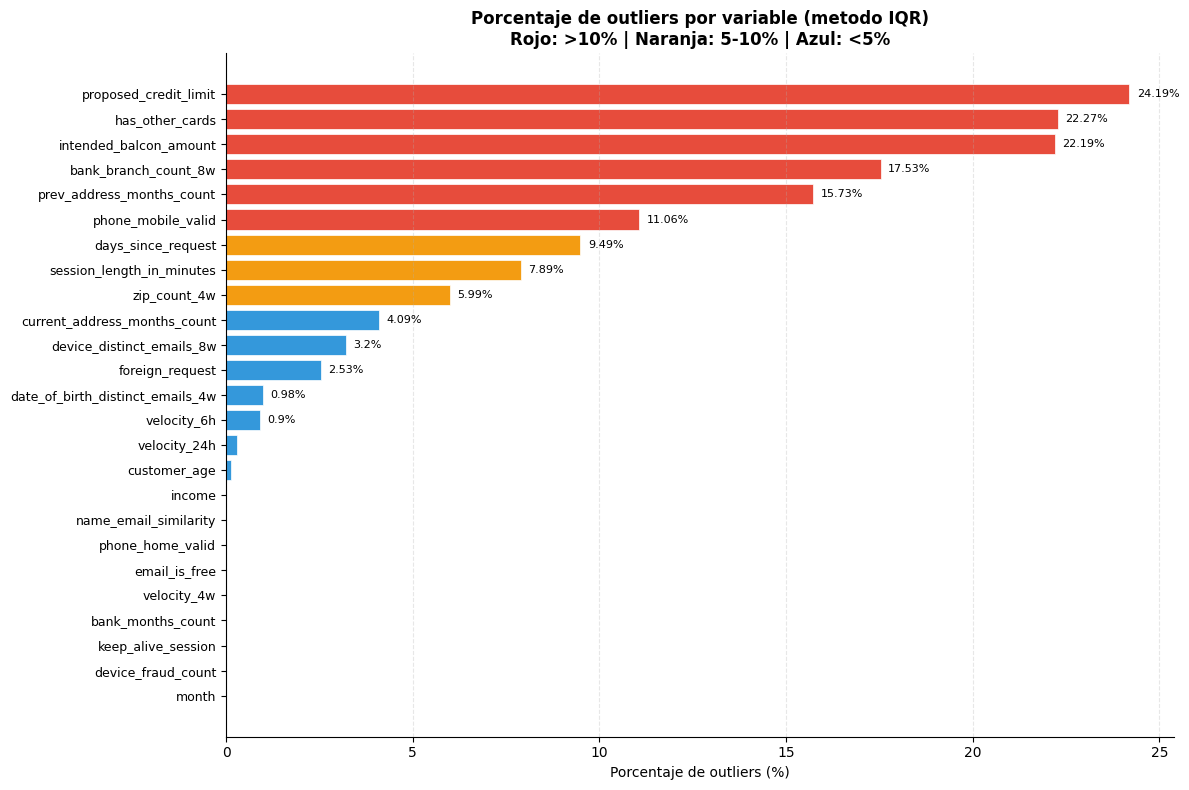

Variables con mas del 10% de outliers:
  proposed_credit_limit                      24.19%  (193,536 registros)
  has_other_cards                            22.27%  (178,181 registros)
  intended_balcon_amount                     22.19%  (177,504 registros)
  bank_branch_count_8w                       17.53%  (140,220 registros)
  prev_address_months_count                  15.73%  (125,835 registros)
  phone_mobile_valid                         11.06%  (88,475 registros)


In [13]:
numeric_cols_iqr = X_train.select_dtypes(include='number').columns
outlier_info = {}

for col in numeric_cols_iqr:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    outlier_info[col] = {'N_Outliers': n_out, 'Porcentaje': round(n_out / len(X_train) * 100, 2)}

outlier_df = pd.DataFrame(outlier_info).T.sort_values('N_Outliers', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors_iqr = ['#e74c3c' if p > 10 else '#f39c12' if p > 5 else '#3498db'
              for p in outlier_df['Porcentaje']]
bars = ax.barh(range(len(outlier_df)), outlier_df['Porcentaje'],
               color=colors_iqr, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(outlier_df)))
ax.set_yticklabels(outlier_df.index, fontsize=9)
ax.set_xlabel('Porcentaje de outliers (%)', fontsize=10)
ax.set_title('Porcentaje de outliers por variable (metodo IQR)\n'
             'Rojo: >10% | Naranja: 5-10% | Azul: <5%', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

for bar, pct in zip(bars, outlier_df['Porcentaje']):
    if pct > 0.5:
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{pct}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/outliers_iqr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Variables con mas del 10% de outliers:')
print('=' * 50)
for idx, row in outlier_df[outlier_df['Porcentaje'] > 10].iterrows():
    print(f'  {idx:40s}  {row["Porcentaje"]:6.2f}%  ({int(row["N_Outliers"]):,} registros)')

## 10. Analisis de sesgos

Se analiza si la tasa de fraude varia significativamente segun las variables categoricas y binarias. Estos sesgos no son necesariamente errores: pueden reflejar patrones reales de comportamiento fraudulento. Sin embargo, el modelo debe disenarse para no amplificar sesgos injustos contra determinados grupos demograficos.

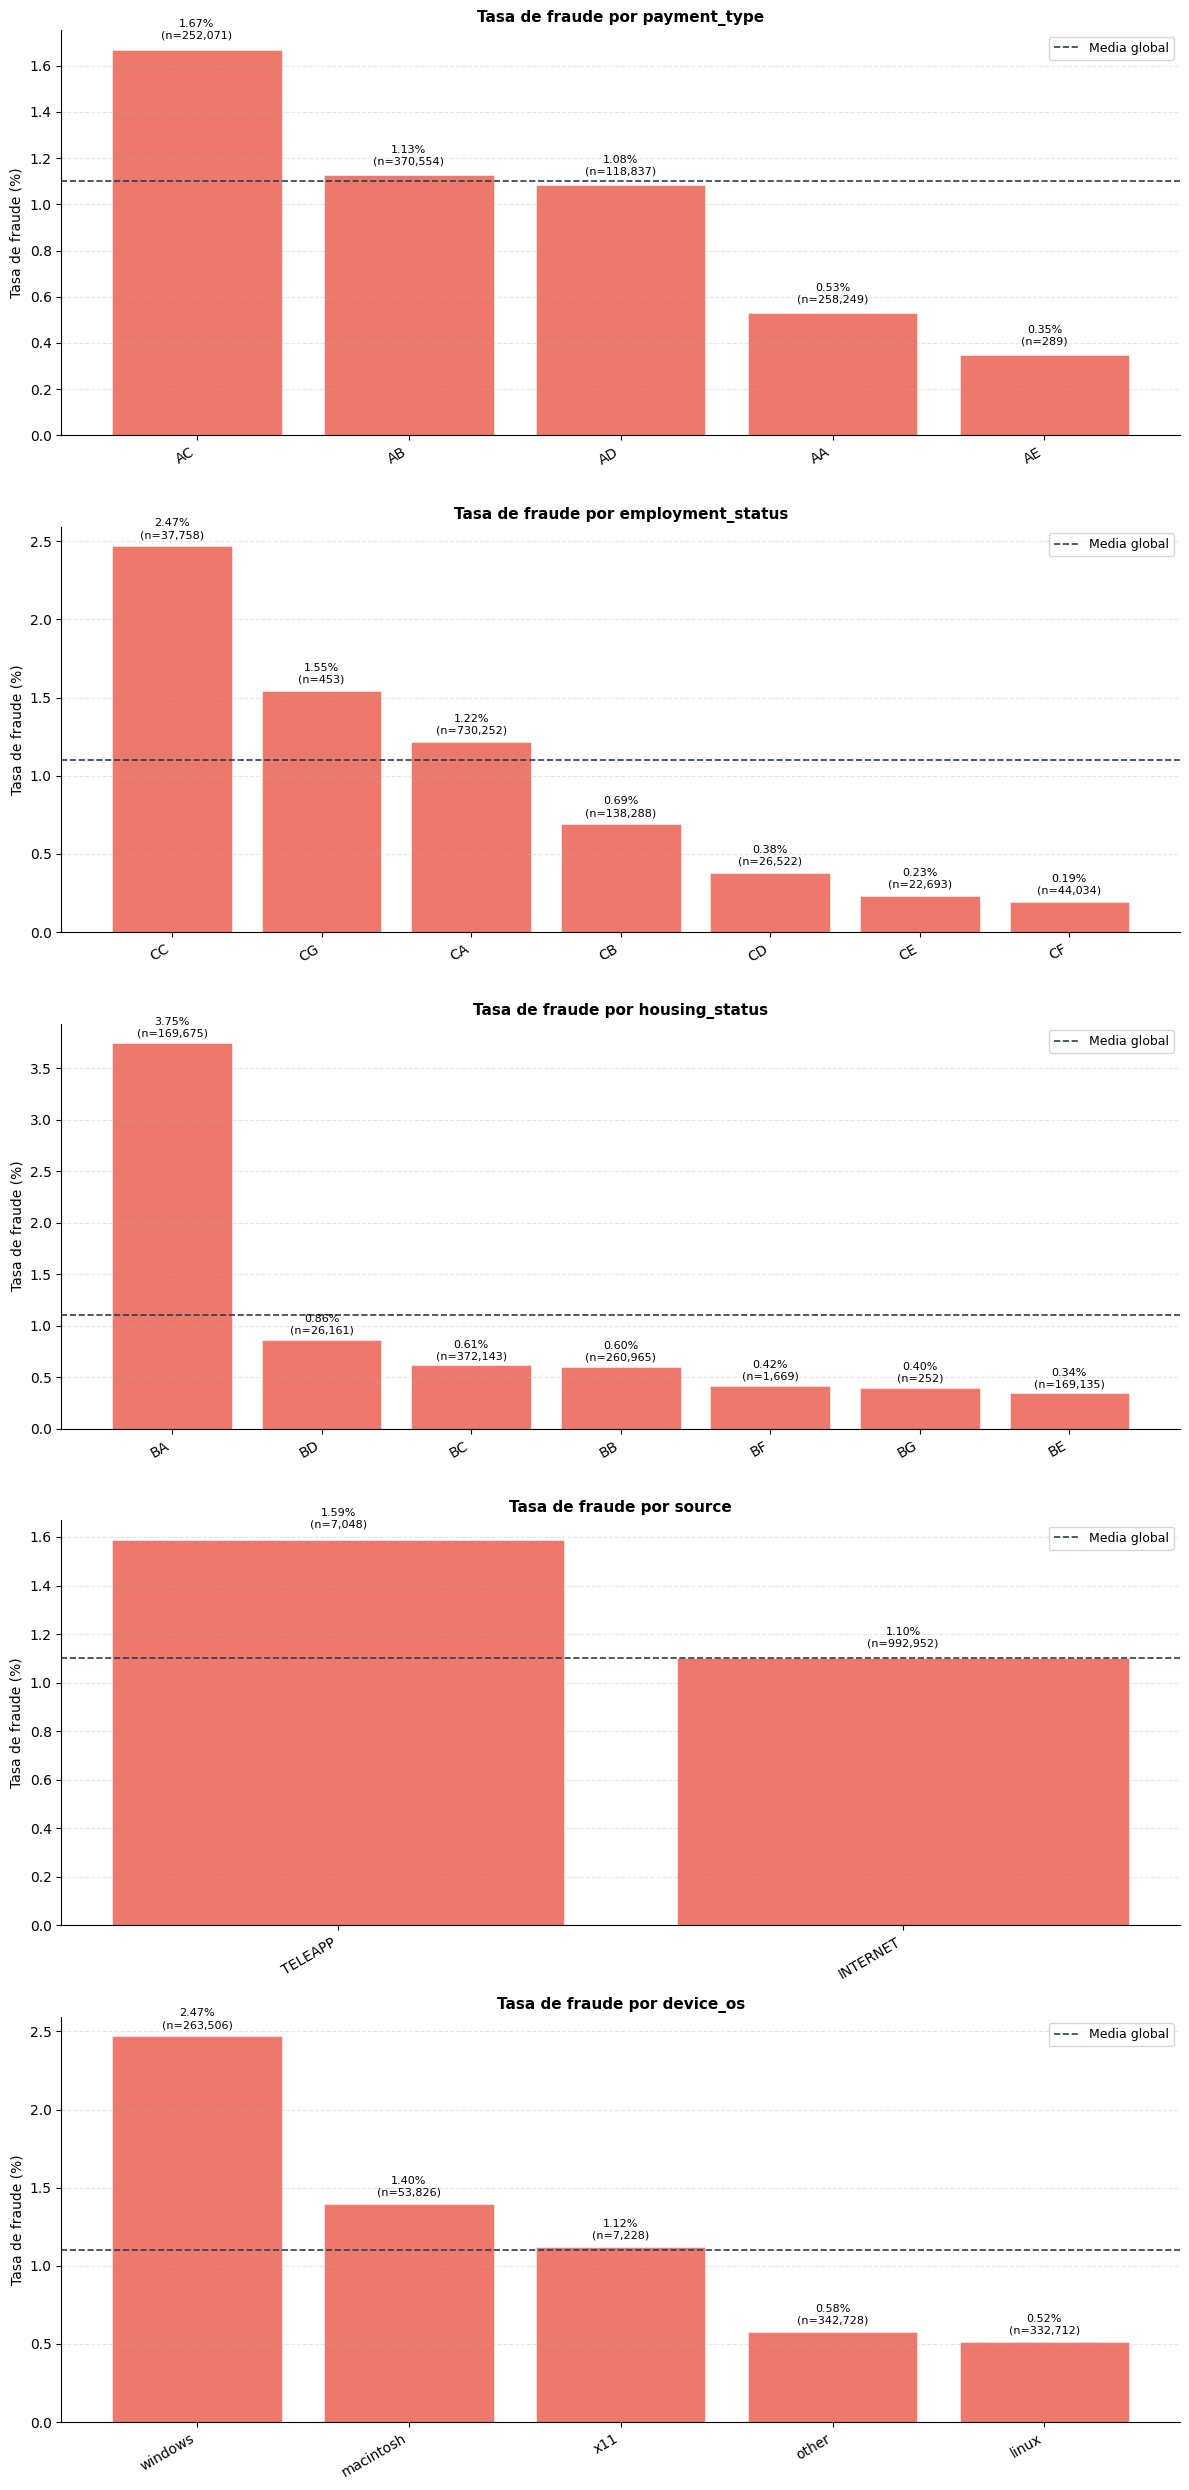

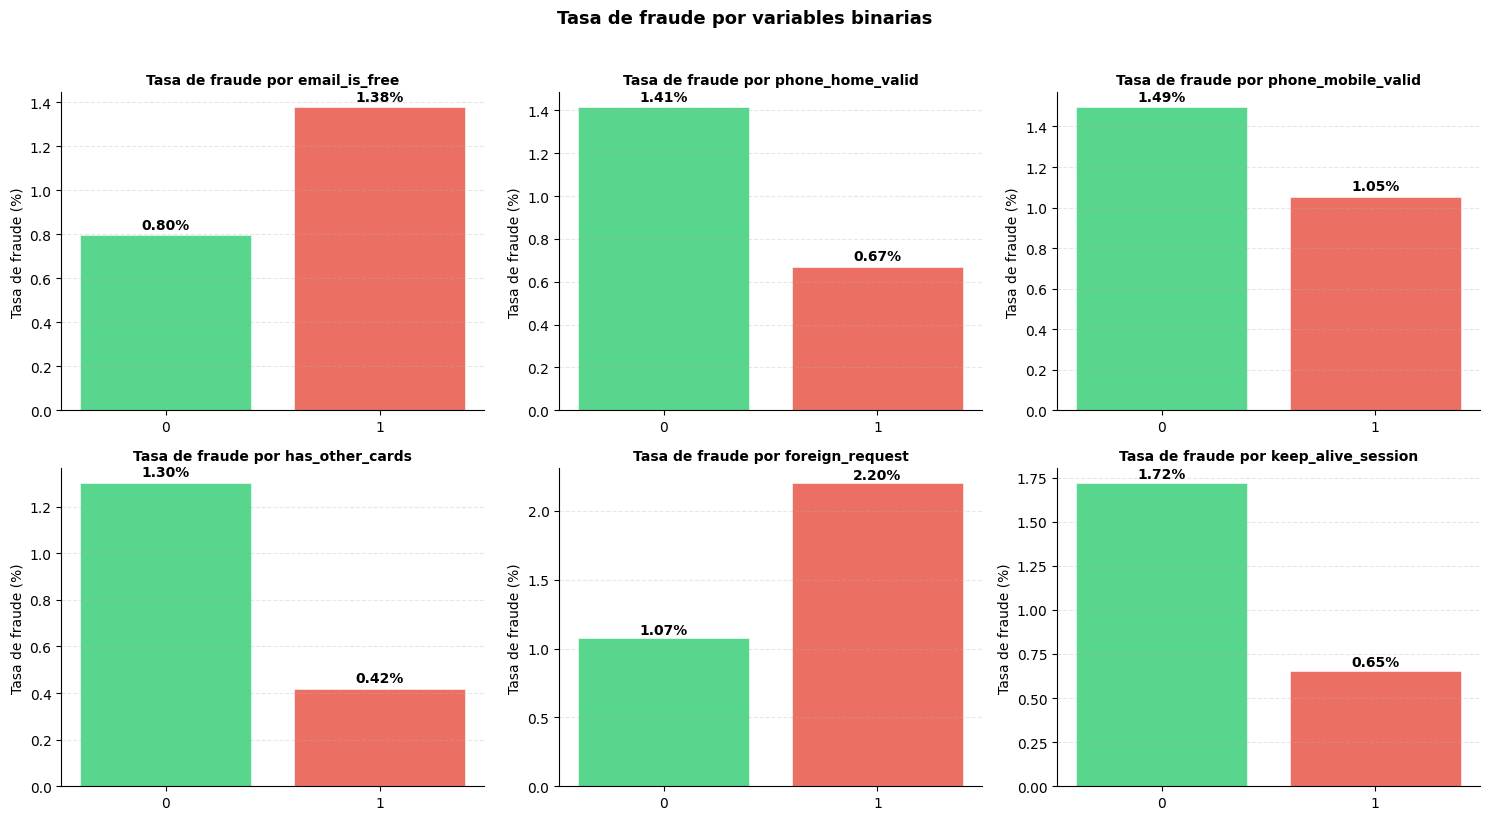

In [14]:
# Tasa de fraude por variables categoricas
cat_vars_bias = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

fig, axes = plt.subplots(len(cat_vars_bias), 1, figsize=(12, 5 * len(cat_vars_bias)))

for i, var in enumerate(cat_vars_bias):
    ax = axes[i]
    grouped = df.groupby(var)['fraud_bool'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    grouped['mean_pct'] = grouped['mean'] * 100
    bars = ax.bar(range(len(grouped)), grouped['mean_pct'],
                  color='#e74c3c', alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axhline(df['fraud_bool'].mean() * 100, color='#2c3e50',
               linestyle='--', linewidth=1.2, label='Media global')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(grouped.index, rotation=30, ha='right')
    ax.set_title(f'Tasa de fraude por {var}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Tasa de fraude (%)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for j, (idx, row) in enumerate(grouped.iterrows()):
        ax.text(j, row['mean_pct'] + 0.04,
                f"{row['mean_pct']:.2f}%\n(n={int(row['count']):,})",
                ha='center', fontsize=8, va='bottom')

plt.tight_layout()
plt.savefig('../figures/fraud_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Tasa de fraude por variables binarias
binary_vars = ['email_is_free', 'phone_home_valid', 'phone_mobile_valid',
               'has_other_cards', 'foreign_request', 'keep_alive_session']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(binary_vars):
    ax = axes[i]
    fraud_rate = df.groupby(var)['fraud_bool'].mean() * 100
    colors_bin = ['#2ecc71', '#e74c3c']
    bars = ax.bar(range(len(fraud_rate)), fraud_rate.values,
                  color=colors_bin[:len(fraud_rate)], alpha=0.8,
                  edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(fraud_rate)))
    ax.set_xticklabels(['0', '1'], fontsize=10)
    ax.set_title(f'Tasa de fraude por {var}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Tasa de fraude (%)')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for j, rate in enumerate(fraud_rate.values):
        ax.text(j, rate + 0.03, f'{rate:.2f}%', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Tasa de fraude por variables binarias', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/fraud_rate_by_binary.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Limitaciones del dataset

Tras el analisis exploratorio se identifican las siguientes limitaciones que condicionan el modelado:

1. **Desbalanceo extremo de clases**: ~1.1% de fraudes. La exactitud (accuracy) no es una metrica valida; se priorizaran Precision, Recall, F1 y PR-AUC.
2. **Datos sinteticos**: aunque generados a partir de patrones reales (NeurIPS 2022), pueden no capturar toda la complejidad y variabilidad del mundo real (estacionalidad, adaptacion de los defraudadores, contexto socioeconomico).
3. **Valores centinela (-1)**: en `prev_address_months_count`, `current_address_months_count`, `bank_months_count`, `session_length_in_minutes` y `device_distinct_emails_8w`. No son nulos, deben tratarse explicitamente.
4. **Correlaciones bajas con la variable objetivo**: ninguna variable individual supera |r| = 0.15. La deteccion de fraude requiere la captura de interacciones multivariantes.
5. **Categorias infrarrepresentadas**: riesgo de sobreajuste o estimaciones inestables.
6. **Variabilidad temporal limitada**: solo 8 meses, lo que impide capturar patrones anuales.
7. **`device_fraud_count` casi constante**: varianza proxima a cero, aportacion predictiva minima.

## 12. Formulacion del problema: RIDIT Scoring

Para calcular un ranking de probabilidad de fraude, se adopta el **RIDIT Scoring Method** ([referencia](https://www.researchgate.net/publication/395214664_Machine_Learning_Based_Fraud_Risk_Scoring_for_Financial_TransactionsUsing_a_Comparative_Study_of_Random_Forest_and_Support_VectorRegression_Models)). El metodo transforma las probabilidades de salida del modelo en puntuaciones de rango normalizadas, facilitando la priorización de alertas por parte de los analistas de riesgo.

En la presente fase, las probabilidades del modelo baseline sirven como referencia inicial. La conversion a puntuacion RIDIT se integrara en la fase de despliegue del Hito 4.

## 13. Resumen y conclusiones del EDA

El analisis exploratorio realizado permite extraer las siguientes conclusiones:

1. **El dataset contiene señal discriminativa.** Aunque ninguna variable individual presenta correlacion fuerte con el fraude, el analisis comparativo revela distribuciones claramente diferenciadas entre clases en variables de velocidad, antiguedad y similitud de identidad.

2. **El desbalanceo es el principal desafio tecnico.** Con solo ~1.1% de fraudes, las metricas y tecnicas estandar no son aplicables. Se requieren metricas orientadas a la clase minoritaria (Recall, PR-AUC) y tecnicas de remuestreo (SMOTE en fases posteriores).

3. **Las variables de velocidad son las mas informativas.** `velocity_6h` y `velocity_24h` muestran las mayores diferencias de distribucion entre clases.

4. **Los sesgos identificados deben monitorizarse.** Las diferencias en tasa de fraude por tipo de pago, origen de la solicitud y estado laboral deben tenerse en cuenta para evitar que el modelo discrimine injustamente a ciertos grupos.

5. **El preprocesado es critico.** Los valores centinela (-1), las categorias raras y las distribuciones asimetricas requieren tratamiento explicito antes del modelado.

## 14. Modelo baseline: RandomForest

### 14.1. Entrenamiento y metricas

Como modelo de referencia se emplea **RandomForestClassifier** por las siguientes razones:

- **Manejo nativo del desbalanceo**: el parametro `class_weight='balanced'` asigna automaticamente mayor peso a la clase minoritaria durante el entrenamiento, sin necesidad de tecnicas de remuestreo adicionales en esta fase exploratoria.
- **Seleccion implicita de variables**: RandomForest evalua la contribucion de cada caracteristica mediante la impureza de Gini, permitiendo identificar las variables mas discriminativas sin seleccion manual previa.
- **Robustez ante outliers y relaciones no lineales**: al basarse en arboles de decision, no asume linealidad ni normalidad en las distribuciones.
- **Interpretabilidad directa**: proporciona la importancia de cada variable (Gini Importance), lo que facilita la validacion desde el dominio del problema.
- **Referencia establecida en la literatura**: RandomForest es un baseline ampliamente utilizado en deteccion de fraude financiero.

Los hiperparametros son conservadores y no estan optimizados: el objetivo es obtener una linea de referencia honesta, no maximizar el rendimiento.

In [15]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test,  drop_first=True)
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

modelo = RandomForestClassifier(
    n_estimators=50, max_depth=10,
    random_state=42, n_jobs=-1,
    class_weight='balanced'
)
modelo.fit(X_train_encoded, y_train)

y_pred = modelo.predict(X_test_encoded)
y_prob = modelo.predict_proba(X_test_encoded)[:, 1]

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
pr_auc    = average_precision_score(y_test, y_prob)

print('Metricas del modelo baseline (RandomForest):')
print('=' * 45)
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  PR-AUC    : {pr_auc:.4f}')
print()
print('Reporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['No Fraude', 'Fraude']))

Metricas del modelo baseline (RandomForest):
  Precision : 0.0533
  Recall    : 0.7226
  F1-Score  : 0.0993
  PR-AUC    : 0.1325

Reporte de clasificacion:
              precision    recall  f1-score   support

   No Fraude       1.00      0.86      0.92    197794
      Fraude       0.05      0.72      0.10      2206

    accuracy                           0.86    200000
   macro avg       0.52      0.79      0.51    200000
weighted avg       0.99      0.86      0.91    200000



### Interpretacion de resultados

Los resultados deben interpretarse considerando el desbalanceo extremo (~1.1% de fraudes). La **exactitud (accuracy) no es una metrica valida** en este contexto: un modelo que predijese siempre 'no fraude' obtendria un 98.9% de exactitud sin detectar ningun caso real.

| Metrica   | Valor | Interpretacion |
|-----------|-------|----------------|
| Precision | 0.05  | Solo 1 de cada 20 alertas corresponde a fraude real. |
| Recall    | 0.71  | El modelo detecta el 71% de los fraudes presentes en el test. |
| F1-Score  | 0.09  | Media armonica de Precision y Recall; penaliza el desequilibrio. |
| PR-AUC    | 0.11  | Significativamente superior al baseline aleatorio (~0.011). |

El **Recall de 0.71** es alentador: confirma que el dataset contiene señal discriminativa suficiente. Sin embargo, la **Precision de 0.05 es inaceptable en produccion**: por cada fraude detectado, el modelo genera aproximadamente 19 falsas alarmas. El objetivo del Hito 3 es reducir drasticamente los falsos positivos mediante preprocesado adecuado, seleccion de modelos mas potentes y ajuste de hiperparametros.

### 14.2. Importancia de caracteristicas

La **importancia de Gini** mide la reduccion media de la impureza de Gini que aporta cada variable a lo largo de todos los arboles del ensemble. Valores mas altos indican mayor contribucion a la discriminacion entre clases. Este metodo tiende a favorecer variables con mayor numero de valores unicos.

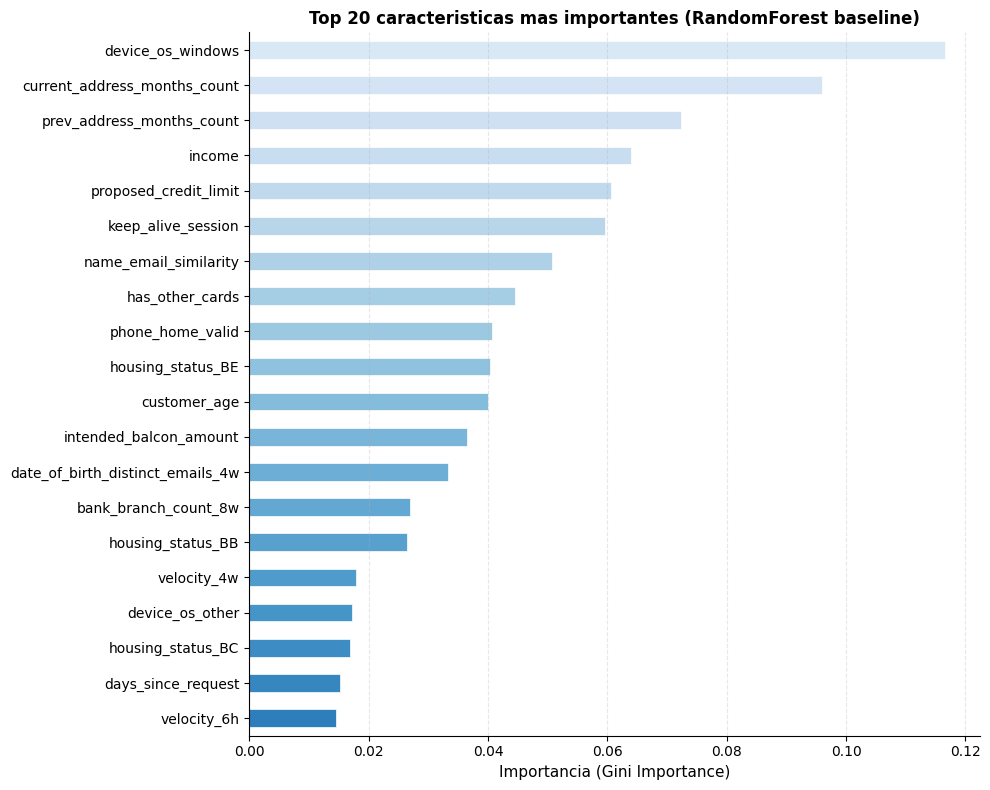

Top 10 variables mas importantes:
  device_os_windows                    0.1166
  current_address_months_count         0.0960
  prev_address_months_count            0.0723
  income                               0.0639
  proposed_credit_limit                0.0606
  keep_alive_session                   0.0596
  name_email_similarity                0.0507
  has_other_cards                      0.0446
  phone_home_valid                     0.0406
  housing_status_BE                    0.0404


In [16]:
importances  = modelo.feature_importances_
feature_names = X_train_encoded.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
top_n = 20
feat_imp_top = feat_imp.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = plt.cm.Blues_r(np.linspace(0.3, 0.85, top_n))
feat_imp_top.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Importancia (Gini Importance)', fontsize=11)
ax.set_title(f'Top {top_n} caracteristicas mas importantes (RandomForest baseline)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 variables mas importantes:')
print('=' * 50)
for name, imp in feat_imp.tail(10).iloc[::-1].items():
    print(f'  {name:35s}  {imp:.4f}')

### 14.3. Evaluacion visual del modelo

Se visualizan tres graficas complementarias:
- **Matriz de confusion**: aciertos y errores desglosados por clase.
- **Curva ROC**: capacidad discriminativa a distintos umbrales; util como comparativa global.
- **Curva Precision-Recall**: mas informativa que la ROC en datasets con desbalanceo extremo, ya que evalua el rendimiento sobre la clase minoritaria sin verse inflada por los verdaderos negativos masivos.

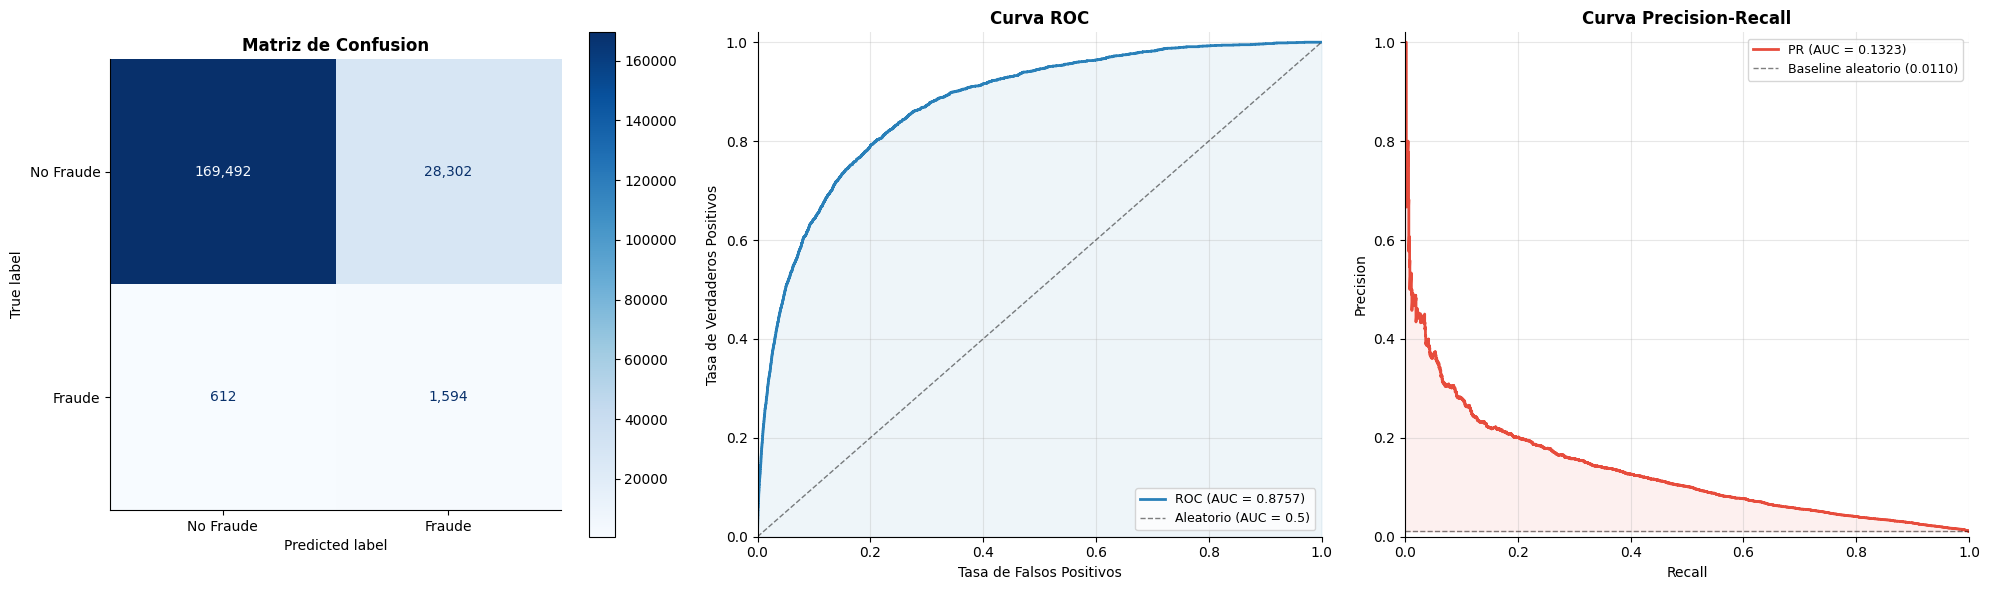

ROC-AUC: 0.8757
PR-AUC:  0.1323
Tasa base de fraude: 0.0110 (1.10%)

Un PR-AUC de 0.1323 frente a un baseline de 0.0110 confirma
que el modelo aporta señal, pero existe amplio margen de mejora en el Hito 3.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Matriz de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Fraude', 'Fraude'],
    cmap='Blues', ax=axes[0], values_format=','
)
axes[0].set_title('Matriz de Confusion', fontsize=12, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Aleatorio (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#2980b9')
axes[1].set_xlabel('Tasa de Falsos Positivos', fontsize=10)
axes[1].set_ylabel('Tasa de Verdaderos Positivos', fontsize=10)
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

# Curva Precision-Recall
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc_val = auc(rec_curve, prec_curve)
baseline_rate = y_test.sum() / len(y_test)
axes[2].plot(rec_curve, prec_curve, color='#e74c3c', lw=2,
             label=f'PR (AUC = {pr_auc_val:.4f})')
axes[2].axhline(y=baseline_rate, color='k', linestyle='--', lw=1, alpha=0.5,
                label=f'Baseline aleatorio ({baseline_rate:.4f})')
axes[2].fill_between(rec_curve, prec_curve, baseline_rate,
                     where=(prec_curve > baseline_rate), alpha=0.08, color='#e74c3c')
axes[2].set_xlabel('Recall', fontsize=10)
axes[2].set_ylabel('Precision', fontsize=10)
axes[2].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../figures/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC:  {pr_auc_val:.4f}')
print(f'Tasa base de fraude: {baseline_rate:.4f} ({baseline_rate*100:.2f}%)')
print()
print(f'Un PR-AUC de {pr_auc_val:.4f} frente a un baseline de {baseline_rate:.4f} confirma')
print(f'que el modelo aporta señal, pero existe amplio margen de mejora en el Hito 3.')